<center><h2> Camptothecin Drug Sensitivity EDA

<center><h3> Creator: Dr. Quincy Snell

**Source:** Genomics of Drug Sensitivity in Cancer (GDSC) – https://www.cancerrxgene.org/

**Description:** *This dataset contains pharmacological response data for the drug Camptothecin across 967 cancer cell lines drawn from the GDSC database. Camptothecin is a topoisomerase I inhibitor used in cancer treatment. The objective of this analysis is to identify features associated with drug resistance, and to prepare the data for building a binary classification model to predict whether a cancer cell line is resistant or sensitive to Camptothecin based on molecular and tissue-level features.*

In [ ]:
# Import Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import scipy.stats as stats
from scipy.stats import skew, norm, probplot, boxcox, f_oneway

import warnings
warnings.filterwarnings("ignore")

In [ ]:
df = pd.read_excel('/content/Cancer_Drug_Dataset.xlsx')
# df = pd.read_csv('filename.csv')

In [ ]:
# First 5 rows
df.head()

,COSMIC_ID,CELL_LINE_NAME,TCGA_DESC,DRUG_ID,DRUG_NAME,LN_IC50,AUC,Z_SCORE,GDSC_Tissue_descriptor_1,GDSC_Tissue_descriptor_2,Cancer_Type_(matching_TCGA_label),Microsatellite_instability_Status_(MSI),Screen_Medium,Growth_Properties,CNA,Gene_Expression,Methylation,TARGET,TARGET_PATHWAY
0,683667,PFSK-1,MB,1003,Camptothecin,-1.463887,0.930220,0.433123,nervous_system,medulloblastoma,MB,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication
1,684057,ES5,UNCLASSIFIED,1003,Camptothecin,-3.360586,0.791072,-0.599569,bone,ewings_sarcoma,NaN,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication
2,684059,ES7,UNCLASSIFIED,1003,Camptothecin,-5.044940,0.592660,-1.516647,bone,ewings_sarcoma,NaN,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication
3,684062,EW-11,UNCLASSIFIED,1003,Camptothecin,-3.741991,0.734047,-0.807232,bone,ewings_sarcoma,NaN,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication
4,684072,SK-ES-1,UNCLASSIFIED,1003,Camptothecin,-5.142961,0.582439,-1.570016,bone,ewings_sarcoma,NaN,MSS/MSI-L,R,Semi-Adherent,Y,Y,Y,TOP1,DNA replication


In [ ]:
# Create RESISTANT outcome variable based on median LN_IC50 (not included in your code professor but this is unique to my dataset)
# (I don't have an outcome column so I want to create one before starting EDA)
median_ic50 = df['LN_IC50'].median()
df['RESISTANT'] = (df['LN_IC50'] > median_ic50).astype(int)

print(f"Median LN_IC50: {median_ic50:.4f}")
print(df['RESISTANT'].value_counts())

Median LN_IC50: -2.4688
RESISTANT
0    484
1    483
Name: count, dtype: int64


In [ ]:
# First 10 rows
df.head(10)

,COSMIC_ID,CELL_LINE_NAME,TCGA_DESC,DRUG_ID,DRUG_NAME,LN_IC50,AUC,Z_SCORE,GDSC_Tissue_descriptor_1,GDSC_Tissue_descriptor_2,Cancer_Type_(matching_TCGA_label),Microsatellite_instability_Status_(MSI),Screen_Medium,Growth_Properties,CNA,Gene_Expression,Methylation,TARGET,TARGET_PATHWAY,RESISTANT
0,683667,PFSK-1,MB,1003,Camptothecin,-1.463887,0.930220,0.433123,nervous_system,medulloblastoma,MB,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication,1
1,684057,ES5,UNCLASSIFIED,1003,Camptothecin,-3.360586,0.791072,-0.599569,bone,ewings_sarcoma,NaN,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication,0
2,684059,ES7,UNCLASSIFIED,1003,Camptothecin,-5.044940,0.592660,-1.516647,bone,ewings_sarcoma,NaN,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication,0
3,684062,EW-11,UNCLASSIFIED,1003,Camptothecin,-3.741991,0.734047,-0.807232,bone,ewings_sarcoma,NaN,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication,0
4,684072,SK-ES-1,UNCLASSIFIED,1003,Camptothecin,-5.142961,0.582439,-1.570016,bone,ewings_sarcoma,NaN,MSS/MSI-L,R,Semi-Adherent,Y,Y,Y,TOP1,DNA replication,0
5,687448,COLO-829,SKCM,1003,Camptothecin,-1.235034,0.867348,0.557727,skin,melanoma,SKCM,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication,1
6,687452,5637,BLCA,1003,Camptothecin,-2.632632,0.834067,-0.203221,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TOP1,DNA replication,0
7,687455,RT4,BLCA,1003,Camptothecin,-2.963191,0.821438,-0.383200,urogenital_system,Bladder,BLCA,MSS/MSI-L,D/F12,Adherent,Y,Y,Y,TOP1,DNA replication,0
8,687457,SW780,BLCA,1003,Camptothecin,-1.449138,0.905050,0.441154,urogenital_system,Bladder,BLCA,MSS/MSI-L,D/F12,Adherent,Y,Y,Y,TOP1,DNA replication,1
9,687459,TCCSUP,BLCA,1003,Camptothecin,-2.350633,0.843430,-0.049682,urogenital_system,Bladder,BLCA,MSS/MSI-L,D/F12,Adherent,Y,Y,Y,TOP1,DNA replication,1


In [ ]:
# Last 5 rows
df.tail()

,COSMIC_ID,CELL_LINE_NAME,TCGA_DESC,DRUG_ID,DRUG_NAME,LN_IC50,AUC,Z_SCORE,GDSC_Tissue_descriptor_1,GDSC_Tissue_descriptor_2,Cancer_Type_(matching_TCGA_label),Microsatellite_instability_Status_(MSI),Screen_Medium,Growth_Properties,CNA,Gene_Expression,Methylation,TARGET,TARGET_PATHWAY,RESISTANT
962,1660034,SNU-407,COREAD,1003,Camptothecin,-1.612538,0.898987,0.352188,large_intestine,large_intestine,COAD/READ,MSI-H,R,Adherent,Y,Y,Y,TOP1,DNA replication,1
963,1660035,SNU-61,COREAD,1003,Camptothecin,1.343563,0.984610,1.961691,large_intestine,large_intestine,COAD/READ,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication,1
964,1660036,SNU-81,COREAD,1003,Camptothecin,0.073547,0.984230,1.270207,large_intestine,large_intestine,COAD/READ,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication,1
965,1674021,SNU-C5,COREAD,1003,Camptothecin,-2.421554,0.835886,-0.088296,large_intestine,large_intestine,COAD/READ,MSI-H,R,Adherent,Y,Y,Y,TOP1,DNA replication,1
966,1789883,DiFi,COREAD,1003,Camptothecin,-2.055725,0.877514,0.110887,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TOP1,DNA replication,1


In [ ]:
df.columns

Index(['COSMIC_ID', 'CELL_LINE_NAME', 'TCGA_DESC', 'DRUG_ID', 'DRUG_NAME',
       'LN_IC50', 'AUC', 'Z_SCORE', 'GDSC_Tissue_descriptor_1',
       'GDSC_Tissue_descriptor_2', 'Cancer_Type_(matching_TCGA_label)',
       'Microsatellite_instability_Status_(MSI)', 'Screen_Medium',
       'Growth_Properties', 'CNA', 'Gene_Expression', 'Methylation', 'TARGET',
       'TARGET_PATHWAY', 'RESISTANT'],
      dtype='object')

In [ ]:
df.shape   # (rows, columns)

(967, 20)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 967 entries, 0 to 966
Data columns (total 20 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   COSMIC_ID                                967 non-null    int64  
 1   CELL_LINE_NAME                           967 non-null    object 
 2   TCGA_DESC                                961 non-null    object 
 3   DRUG_ID                                  967 non-null    int64  
 4   DRUG_NAME                                967 non-null    object 
 5   LN_IC50                                  967 non-null    float64
 6   AUC                                      967 non-null    float64
 7   Z_SCORE                                  967 non-null    float64
 8   GDSC_Tissue_descriptor_1                 928 non-null    object 
 9   GDSC_Tissue_descriptor_2                 928 non-null    object 
 10  Cancer_Type_(matching_TCGA_label)        763 non-n

In [ ]:
df.describe()

,COSMIC_ID,DRUG_ID,LN_IC50,AUC,Z_SCORE,RESISTANT
count,9.670000e+02,967.0,967.000000,967.000000,967.000000,967.000000
mean,9.962377e+05,1003.0,-2.256686,0.828461,0.001470,0.499483
std,2.240195e+05,0.0,1.835683,0.112394,0.999471,0.500258
min,6.836670e+05,1003.0,-5.881366,0.482402,-1.972054,0.000000
25%,9.068135e+05,1003.0,-3.604763,0.751705,-0.732515,0.000000
50%,9.097290e+05,1003.0,-2.468786,0.845006,-0.114012,0.000000
75%,1.240154e+06,1003.0,-1.103195,0.923250,0.629509,1.000000
max,1.789883e+06,1003.0,3.692250,0.994588,3.240477,1.000000


In [ ]:
# Transpose table above
df.describe().T

,count,mean,std,min,25%,50%,75%,max
COSMIC_ID,967.0,996237.670114,224019.472804,683667.000000,906813.500000,909729.000000,1.240154e+06,1.789883e+06
DRUG_ID,967.0,1003.000000,0.000000,1003.000000,1003.000000,1003.000000,1.003000e+03,1.003000e+03
LN_IC50,967.0,-2.256686,1.835683,-5.881366,-3.604763,-2.468786,-1.103195e+00,3.692250e+00
AUC,967.0,0.828461,0.112394,0.482402,0.751705,0.845006,9.232500e-01,9.945880e-01
Z_SCORE,967.0,0.001470,0.999471,-1.972054,-0.732515,-0.114012,6.295095e-01,3.240477e+00
RESISTANT,967.0,0.499483,0.500258,0.000000,0.000000,0.000000,1.000000e+00,1.000000e+00


In [ ]:
# Reduce number of decimals
pd.set_option('display.float_format', lambda x: '%.2f' % x)
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
COSMIC_ID,967.00,NaN,NaN,NaN,996237.67,224019.47,683667.00,906813.50,909729.00,1240153.50,1789883.00
CELL_LINE_NAME,967,967,DiFi,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TCGA_DESC,961,32,UNCLASSIFIED,180,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DRUG_ID,967.00,NaN,NaN,NaN,1003.00,0.00,1003.00,1003.00,1003.00,1003.00,1003.00
DRUG_NAME,967,1,Camptothecin,967,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LN_IC50,967.00,NaN,NaN,NaN,-2.26,1.84,-5.88,-3.60,-2.47,-1.10,3.69
AUC,967.00,NaN,NaN,NaN,0.83,0.11,0.48,0.75,0.85,0.92,0.99
Z_SCORE,967.00,NaN,NaN,NaN,0.00,1.00,-1.97,-0.73,-0.11,0.63,3.24
GDSC_Tissue_descriptor_1,928,19,lung_NSCLC,107,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GDSC_Tissue_descriptor_2,928,54,lung_NSCLC_adenocarcinoma,64,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# To get description for just one variable
print(df.Growth_Properties.describe())

count          928
unique           3
top       Adherent
freq           669
Name: Growth_Properties, dtype: object


In [ ]:
# Count number of responses for each variable
df.count()

,0
COSMIC_ID,967
CELL_LINE_NAME,967
TCGA_DESC,961
DRUG_ID,967
DRUG_NAME,967
LN_IC50,967
AUC,967
Z_SCORE,967
GDSC_Tissue_descriptor_1,928
GDSC_Tissue_descriptor_2,928


In [ ]:
# Count of responses in each category for the dependent variable
# 0 = Sensitive, 1 = Resistant
df["RESISTANT"].value_counts()

,count
RESISTANT,
0,484
1,483


In [ ]:
# Look at 15 random rows
np.random.seed(1)
df.sample(n=15)

,COSMIC_ID,CELL_LINE_NAME,TCGA_DESC,DRUG_ID,DRUG_NAME,LN_IC50,AUC,Z_SCORE,GDSC_Tissue_descriptor_1,GDSC_Tissue_descriptor_2,Cancer_Type_(matching_TCGA_label),Microsatellite_instability_Status_(MSI),Screen_Medium,Growth_Properties,CNA,Gene_Expression,Methylation,TARGET,TARGET_PATHWAY,RESISTANT
242,906814,COLO-792,SKCM,1003,Camptothecin,-0.21,0.96,1.11,skin,melanoma,SKCM,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication,1
858,1299062,SW1271,SCLC,1003,Camptothecin,-1.26,0.85,0.54,lung_SCLC,lung_small_cell_carcinoma,SCLC,MSS/MSI-L,D/F12,Adherent,Y,Y,N,TOP1,DNA replication,1
634,925345,NOS-1,UNCLASSIFIED,1003,Camptothecin,0.28,0.98,1.38,bone,osteosarcoma,NaN,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication,1
507,909759,SW982,UNCLASSIFIED,1003,Camptothecin,-4.07,0.70,-0.99,soft_tissue,soft_tissue_other,NaN,MSS/MSI-L,D/F12,Adherent,Y,Y,Y,TOP1,DNA replication,0
347,907312,KU-19-19,BLCA,1003,Camptothecin,-3.42,0.78,-0.63,urogenital_system,Bladder,BLCA,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication,0
258,906836,DEL,UNCLASSIFIED,1003,Camptothecin,-5.28,0.57,-1.64,lymphoma,lymphoid_neoplasm other,NaN,MSS/MSI-L,R,Suspension,Y,Y,Y,TOP1,DNA replication,0
881,1327771,JURL-MK1,LCML,1003,Camptothecin,-4.48,0.68,-1.21,leukemia,chronic_myeloid_leukaemia,LCML,MSS/MSI-L,R,Suspension,Y,Y,Y,TOP1,DNA replication,0
268,906848,ECC10,UNCLASSIFIED,1003,Camptothecin,-3.06,0.83,-0.44,digestive_system,stomach,NaN,MSS/MSI-L,R,Suspension,Y,Y,Y,TOP1,DNA replication,0
35,687816,NCI-H2228,LUAD,1003,Camptothecin,-2.71,0.79,-0.25,lung_NSCLC,lung_NSCLC_adenocarcinoma,LUAD,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication,0
78,724839,SW756,CESC,1003,Camptothecin,-2.68,0.80,-0.23,urogenital_system,cervix,CESC,MSS/MSI-L,D/F12,Adherent,Y,Y,Y,TOP1,DNA replication,0


In [ ]:
# Check for duplicate data
df[df.duplicated()].count()

,0
COSMIC_ID,0
CELL_LINE_NAME,0
TCGA_DESC,0
DRUG_ID,0
DRUG_NAME,0
LN_IC50,0
AUC,0
Z_SCORE,0
GDSC_Tissue_descriptor_1,0
GDSC_Tissue_descriptor_2,0


In [ ]:
# Fix data types

# Dependent variable
df['RESISTANT'] = df['RESISTANT'].astype('int') # binary: 0 = sensitive, 1 = resistant

# Continuous numeric features
df['LN_IC50'] = df['LN_IC50'].astype('float')
df['AUC'] = df['AUC'].astype('float')
df['Z_SCORE'] = df['Z_SCORE'].astype('float')

# Categorical features
df['TCGA_DESC'] = df['TCGA_DESC'].astype('category')                          # 32 unique
df['GDSC_Tissue_descriptor_1'] = df['GDSC_Tissue_descriptor_1'].astype('category')   # 19 unique
df['GDSC_Tissue_descriptor_2'] = df['GDSC_Tissue_descriptor_2'].astype('category')   # 54 unique
df['Cancer_Type_(matching_TCGA_label)'] = df['Cancer_Type_(matching_TCGA_label)'].astype('category')  # 31 unique
df['Microsatellite_instability_Status_(MSI)'] = df['Microsatellite_instability_Status_(MSI)'].astype('category')  # 2 unique
df['Screen_Medium'] = df['Screen_Medium'].astype('category')                  # 2 unique
df['Growth_Properties'] = df['Growth_Properties'].astype('category')          # 3 unique

# Binary Y/N flags - category
df['CNA'] = df['CNA'].astype('category')                  # Y / N
df['Gene_Expression'] = df['Gene_Expression'].astype('category')  # Y / N
df['Methylation'] = df['Methylation'].astype('category')  # Y / N

In [ ]:
# Check to see if data type was changed
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 967 entries, 0 to 966
Data columns (total 20 columns):
 #   Column                                   Non-Null Count  Dtype   
---  ------                                   --------------  -----   
 0   COSMIC_ID                                967 non-null    int64   
 1   CELL_LINE_NAME                           967 non-null    object  
 2   TCGA_DESC                                961 non-null    category
 3   DRUG_ID                                  967 non-null    int64   
 4   DRUG_NAME                                967 non-null    object  
 5   LN_IC50                                  967 non-null    float64 
 6   AUC                                      967 non-null    float64 
 7   Z_SCORE                                  967 non-null    float64 
 8   GDSC_Tissue_descriptor_1                 928 non-null    category
 9   GDSC_Tissue_descriptor_2                 928 non-null    category
 10  Cancer_Type_(matching_TCGA_label)     

In [ ]:
# Count number of missing values
df.isnull().sum()

,0
COSMIC_ID,0
CELL_LINE_NAME,0
TCGA_DESC,6
DRUG_ID,0
DRUG_NAME,0
LN_IC50,0
AUC,0
Z_SCORE,0
GDSC_Tissue_descriptor_1,39
GDSC_Tissue_descriptor_2,39


In [ ]:
df.select_dtypes(include=['int', 'float']).mean()

,0
COSMIC_ID,996237.67
DRUG_ID,1003.00
LN_IC50,-2.26
AUC,0.83
Z_SCORE,0.00
RESISTANT,0.50


In [ ]:
df.select_dtypes(include=['int', 'float']).median()

,0
COSMIC_ID,909729.00
DRUG_ID,1003.00
LN_IC50,-2.47
AUC,0.85
Z_SCORE,-0.11
RESISTANT,0.00


In [ ]:
df['RESISTANT'].mode()

,RESISTANT
0,0


In [ ]:
df.select_dtypes(include=['int', 'float']).quantile(.25)

,0.25
COSMIC_ID,906813.50
DRUG_ID,1003.00
LN_IC50,-3.60
AUC,0.75
Z_SCORE,-0.73
RESISTANT,0.00


In [ ]:
df.select_dtypes(include=['int', 'float']).quantile(.50)

,0.50
COSMIC_ID,909729.00
DRUG_ID,1003.00
LN_IC50,-2.47
AUC,0.85
Z_SCORE,-0.11
RESISTANT,0.00


In [ ]:
df.select_dtypes(include=['int', 'float']).quantile(.75)

,0.75
COSMIC_ID,1240153.50
DRUG_ID,1003.00
LN_IC50,-1.10
AUC,0.92
Z_SCORE,0.63
RESISTANT,1.00


In [ ]:
# Quartiles and calculated IQR
Q1 = df.select_dtypes(include=['int', 'float']).quantile(0.25)
Q3 = df.select_dtypes(include=['int', 'float']).quantile(0.75)
IQR_df = Q3-Q1
print(IQR_df)

COSMIC_ID   333340.00
DRUG_ID          0.00
LN_IC50          2.50
AUC              0.17
Z_SCORE          1.36
RESISTANT        1.00
dtype: float64


In [ ]:
# Range
df.select_dtypes(include=['int', 'float']).max()-df.select_dtypes(include=['int', 'float']).min()

,0
COSMIC_ID,1106216.00
DRUG_ID,0.00
LN_IC50,9.57
AUC,0.51
Z_SCORE,5.21
RESISTANT,1.00


In [ ]:
df.select_dtypes(include=['int', 'float']).var()

,0
COSMIC_ID,50184724195.18
DRUG_ID,0.00
LN_IC50,3.37
AUC,0.01
Z_SCORE,1.00
RESISTANT,0.25


In [ ]:
df.select_dtypes(include=['int', 'float']).std()

,0
COSMIC_ID,224019.47
DRUG_ID,0.00
LN_IC50,1.84
AUC,0.11
Z_SCORE,1.00
RESISTANT,0.50


In [ ]:
# Group by dependent variable and Growth Properties
df.groupby(["RESISTANT"])["Growth_Properties"].value_counts(ascending=False)

RESISTANT  Growth_Properties
0          Adherent             268
           Suspension           179
           Semi-Adherent         19
1          Adherent             401
           Suspension            51
           Semi-Adherent         10
Name: count, dtype: int64

In [ ]:
# Assessing skewness

# Less than -1 = highly skewed
# Between -1 and -0.5 = moderately skewed
# Between -0.5 and 0.5 = fairly symmetrical
# Between 0.5 and 1 = moderately skewed
# Greater than 1 = highly skewed

df_skewed=df.select_dtypes(include=['int', 'float']).apply(lambda x: skew(x.dropna())).sort_values(ascending=False)
df_skewed

,0
COSMIC_ID,0.87
Z_SCORE,0.50
LN_IC50,0.50
RESISTANT,0.00
AUC,-0.59
DRUG_ID,NaN


In [ ]:
# Rename long column names for readability
df.rename({'Microsatellite_instability_Status_(MSI)': 'MSI'}, axis=1, inplace=True)
df.rename({'Cancer_Type_(matching_TCGA_label)': 'Cancer_Type'}, axis=1, inplace=True)
df

,COSMIC_ID,CELL_LINE_NAME,TCGA_DESC,DRUG_ID,DRUG_NAME,LN_IC50,AUC,Z_SCORE,GDSC_Tissue_descriptor_1,GDSC_Tissue_descriptor_2,Cancer_Type,MSI,Screen_Medium,Growth_Properties,CNA,Gene_Expression,Methylation,TARGET,TARGET_PATHWAY,RESISTANT
0,683667,PFSK-1,MB,1003,Camptothecin,-1.46,0.93,0.43,nervous_system,medulloblastoma,MB,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication,1
1,684057,ES5,UNCLASSIFIED,1003,Camptothecin,-3.36,0.79,-0.60,bone,ewings_sarcoma,NaN,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication,0
2,684059,ES7,UNCLASSIFIED,1003,Camptothecin,-5.04,0.59,-1.52,bone,ewings_sarcoma,NaN,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication,0
3,684062,EW-11,UNCLASSIFIED,1003,Camptothecin,-3.74,0.73,-0.81,bone,ewings_sarcoma,NaN,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication,0
4,684072,SK-ES-1,UNCLASSIFIED,1003,Camptothecin,-5.14,0.58,-1.57,bone,ewings_sarcoma,NaN,MSS/MSI-L,R,Semi-Adherent,Y,Y,Y,TOP1,DNA replication,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
962,1660034,SNU-407,COREAD,1003,Camptothecin,-1.61,0.90,0.35,large_intestine,large_intestine,COAD/READ,MSI-H,R,Adherent,Y,Y,Y,TOP1,DNA replication,1
963,1660035,SNU-61,COREAD,1003,Camptothecin,1.34,0.98,1.96,large_intestine,large_intestine,COAD/READ,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication,1
964,1660036,SNU-81,COREAD,1003,Camptothecin,0.07,0.98,1.27,large_intestine,large_intestine,COAD/READ,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication,1
965,1674021,SNU-C5,COREAD,1003,Camptothecin,-2.42,0.84,-0.09,large_intestine,large_intestine,COAD/READ,MSI-H,R,Adherent,Y,Y,Y,TOP1,DNA replication,1


# Exploratory Data Analysis

In [ ]:
# Pearson correlation (Note: categorical variables will be excluded)
df.select_dtypes(include=['int', 'float']).corr()

,COSMIC_ID,DRUG_ID,LN_IC50,AUC,Z_SCORE,RESISTANT
COSMIC_ID,1.00,NaN,0.04,0.04,0.04,0.05
DRUG_ID,NaN,NaN,NaN,NaN,NaN,NaN
LN_IC50,0.04,NaN,1.00,0.92,1.00,0.81
AUC,0.04,NaN,0.92,1.00,0.92,0.80
Z_SCORE,0.04,NaN,1.00,0.92,1.00,0.81
RESISTANT,0.05,NaN,0.81,0.80,0.81,1.00


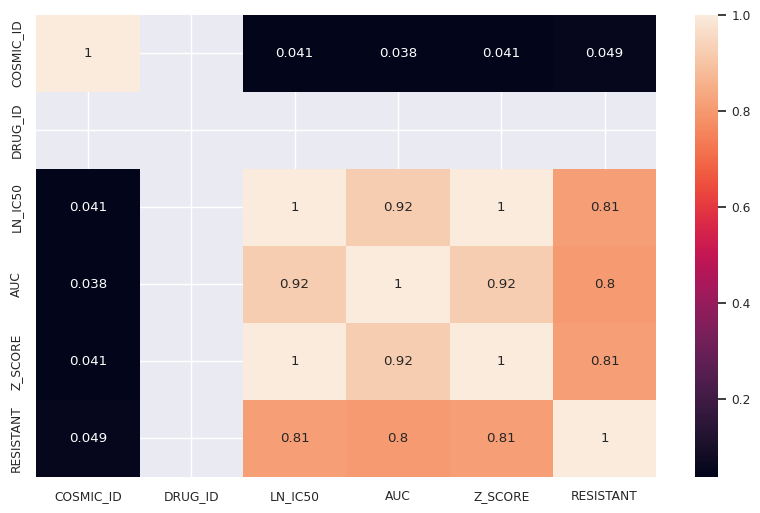

In [ ]:
plt.figure(figsize=(10,6))
sns.set(font_scale=0.8)
plt.rcParams["axes.labelsize"] = 0.5
sns.heatmap(df.select_dtypes(include=['int', 'float']).corr(), annot=True);

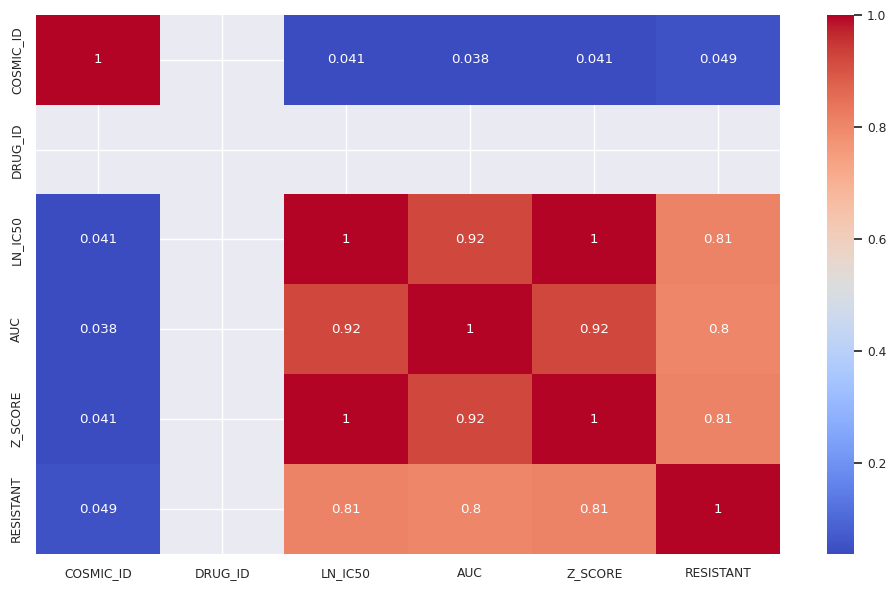

In [ ]:
# To get a different color
plt.figure(figsize=(12, 7))
sns.heatmap(df.select_dtypes(include=['int', 'float']).corr(), annot=True, cmap="coolwarm");

In [ ]:
# Spearman Rank (also called Spearman's Rho) correlation
df.select_dtypes(include=['int', 'float']).corr(method='spearman')

,COSMIC_ID,DRUG_ID,LN_IC50,AUC,Z_SCORE,RESISTANT
COSMIC_ID,1.00,NaN,0.01,0.01,0.01,0.03
DRUG_ID,NaN,NaN,NaN,NaN,NaN,NaN
LN_IC50,0.01,NaN,1.00,0.97,1.00,0.87
AUC,0.01,NaN,0.97,1.00,0.97,0.85
Z_SCORE,0.01,NaN,1.00,0.97,1.00,0.87
RESISTANT,0.03,NaN,0.87,0.85,0.87,1.00


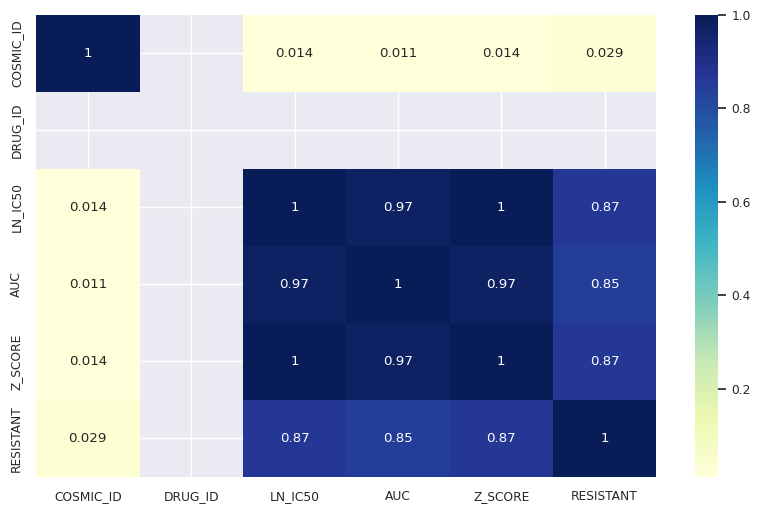

In [ ]:
# Get correlation map for Spearman results
plt.figure(figsize=(10,6))
sns.set(font_scale=0.8)
plt.rcParams["axes.labelsize"] = 0.5
sns.heatmap(df.select_dtypes(include=['int', 'float']).corr(method='spearman'), annot=True, cmap="YlGnBu");

In [ ]:
# Phi_K correlation for all variables (handles categorical + numeric)
! pip install phik
import phik
from phik import resources, report

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 13.7 MB/s eta 0:00:00


In [ ]:
interval_cols = ['LN_IC50', 'AUC', 'Z_SCORE']

df_phik = df.copy()
cat_cols = df_phik.select_dtypes(include='category').columns
df_phik[cat_cols] = df_phik[cat_cols].astype(str)

df_phik.phik_matrix(interval_cols=interval_cols)

,COSMIC_ID,CELL_LINE_NAME,TCGA_DESC,LN_IC50,AUC,Z_SCORE,GDSC_Tissue_descriptor_1,GDSC_Tissue_descriptor_2,Cancer_Type,MSI,Screen_Medium,Growth_Properties,CNA,Gene_Expression,Methylation,RESISTANT
COSMIC_ID,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
CELL_LINE_NAME,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
TCGA_DESC,1.00,1.00,1.00,0.47,0.50,0.47,0.99,1.00,1.00,0.69,0.71,0.77,0.66,0.62,0.61,0.49
LN_IC50,1.00,1.00,0.47,1.00,0.93,1.00,0.54,0.53,0.46,0.00,0.17,0.44,0.00,0.00,0.00,0.99
AUC,1.00,1.00,0.50,0.93,1.00,0.93,0.51,0.56,0.49,0.00,0.20,0.41,0.00,0.09,0.00,0.99
Z_SCORE,1.00,1.00,0.47,1.00,0.93,1.00,0.54,0.53,0.46,0.00,0.17,0.44,0.00,0.00,0.00,0.99
GDSC_Tissue_descriptor_1,1.00,1.00,0.99,0.54,0.51,0.54,1.00,1.00,0.99,0.82,0.89,0.96,0.86,0.86,0.86,0.56
GDSC_Tissue_descriptor_2,1.00,1.00,1.00,0.53,0.56,0.53,1.00,1.00,1.00,0.87,0.92,0.93,0.90,0.89,0.89,0.57
Cancer_Type,1.00,1.00,1.00,0.46,0.49,0.46,0.99,1.00,1.00,0.59,0.58,0.77,0.51,0.43,0.43,0.52
MSI,1.00,1.00,0.69,0.00,0.00,0.00,0.82,0.87,0.59,1.00,0.89,0.59,0.89,0.89,0.91,0.02


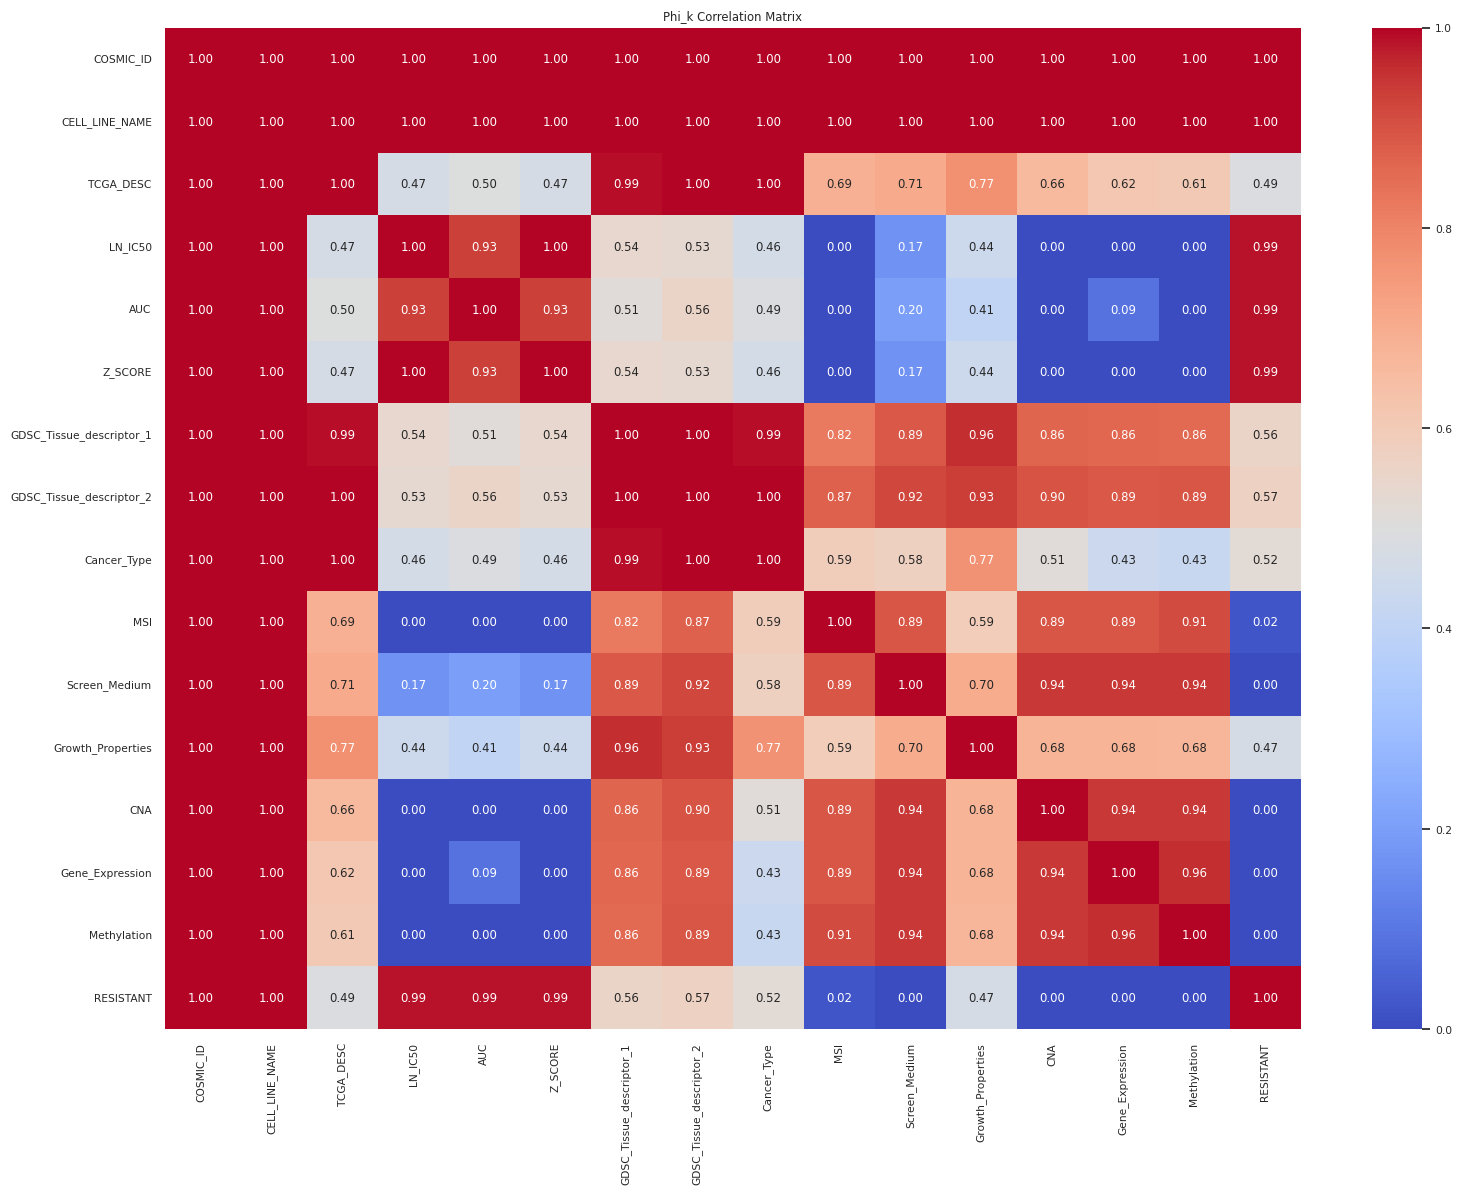

In [ ]:
# Create correlation map based on phi_k findings
interval_cols = ['LN_IC50', 'AUC', 'Z_SCORE']

df_phik = df.copy()
cat_cols = df_phik.select_dtypes(include='category').columns
df_phik[cat_cols] = df_phik[cat_cols].astype(str)

plt.figure(figsize=(16, 12))
sns.set(font_scale=0.7)
sns.heatmap(df_phik.phik_matrix(interval_cols=interval_cols), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Phi_k Correlation Matrix")
plt.tight_layout()
plt.show()

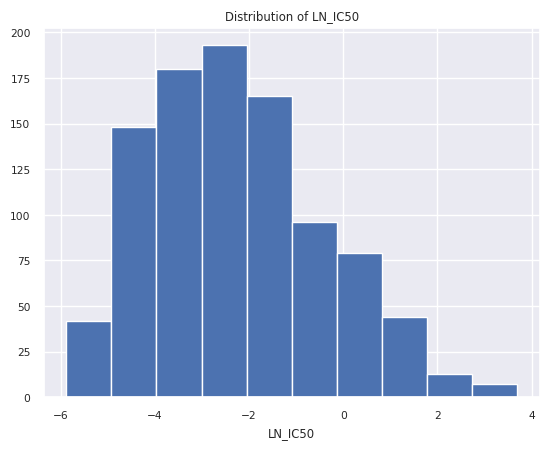

In [ ]:
# Histogram of LN_IC50 (primary drug response variable)
plt.hist(df['LN_IC50'], color='b');
plt.xlabel('LN_IC50')
plt.title('Distribution of LN_IC50');

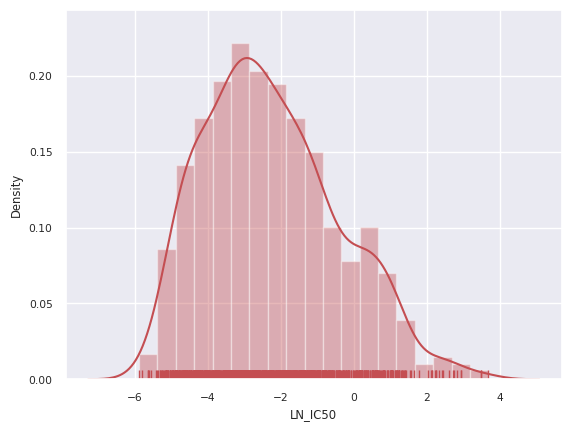

In [ ]:
# Distribution plot of LN_IC50
sns.distplot(df['LN_IC50'], color='r', rug=True);

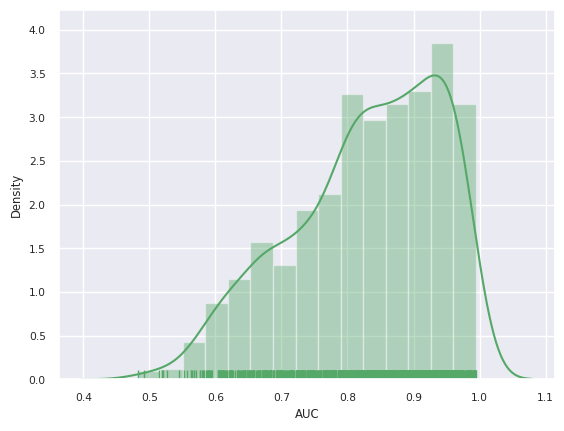

In [ ]:
# Distribution plot of AUC
sns.distplot(df['AUC'], color='g', rug=True);

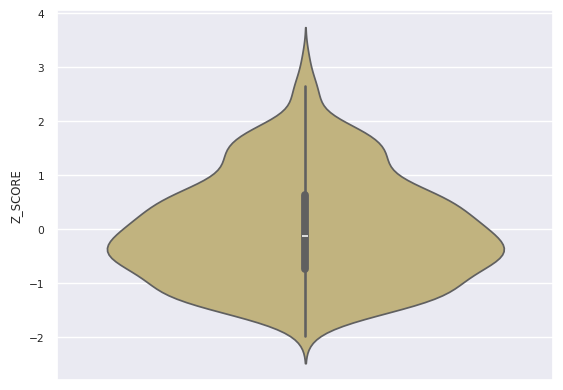

In [ ]:
# Violin plot of Z_SCORE
sns.violinplot(df['Z_SCORE'], color='y');

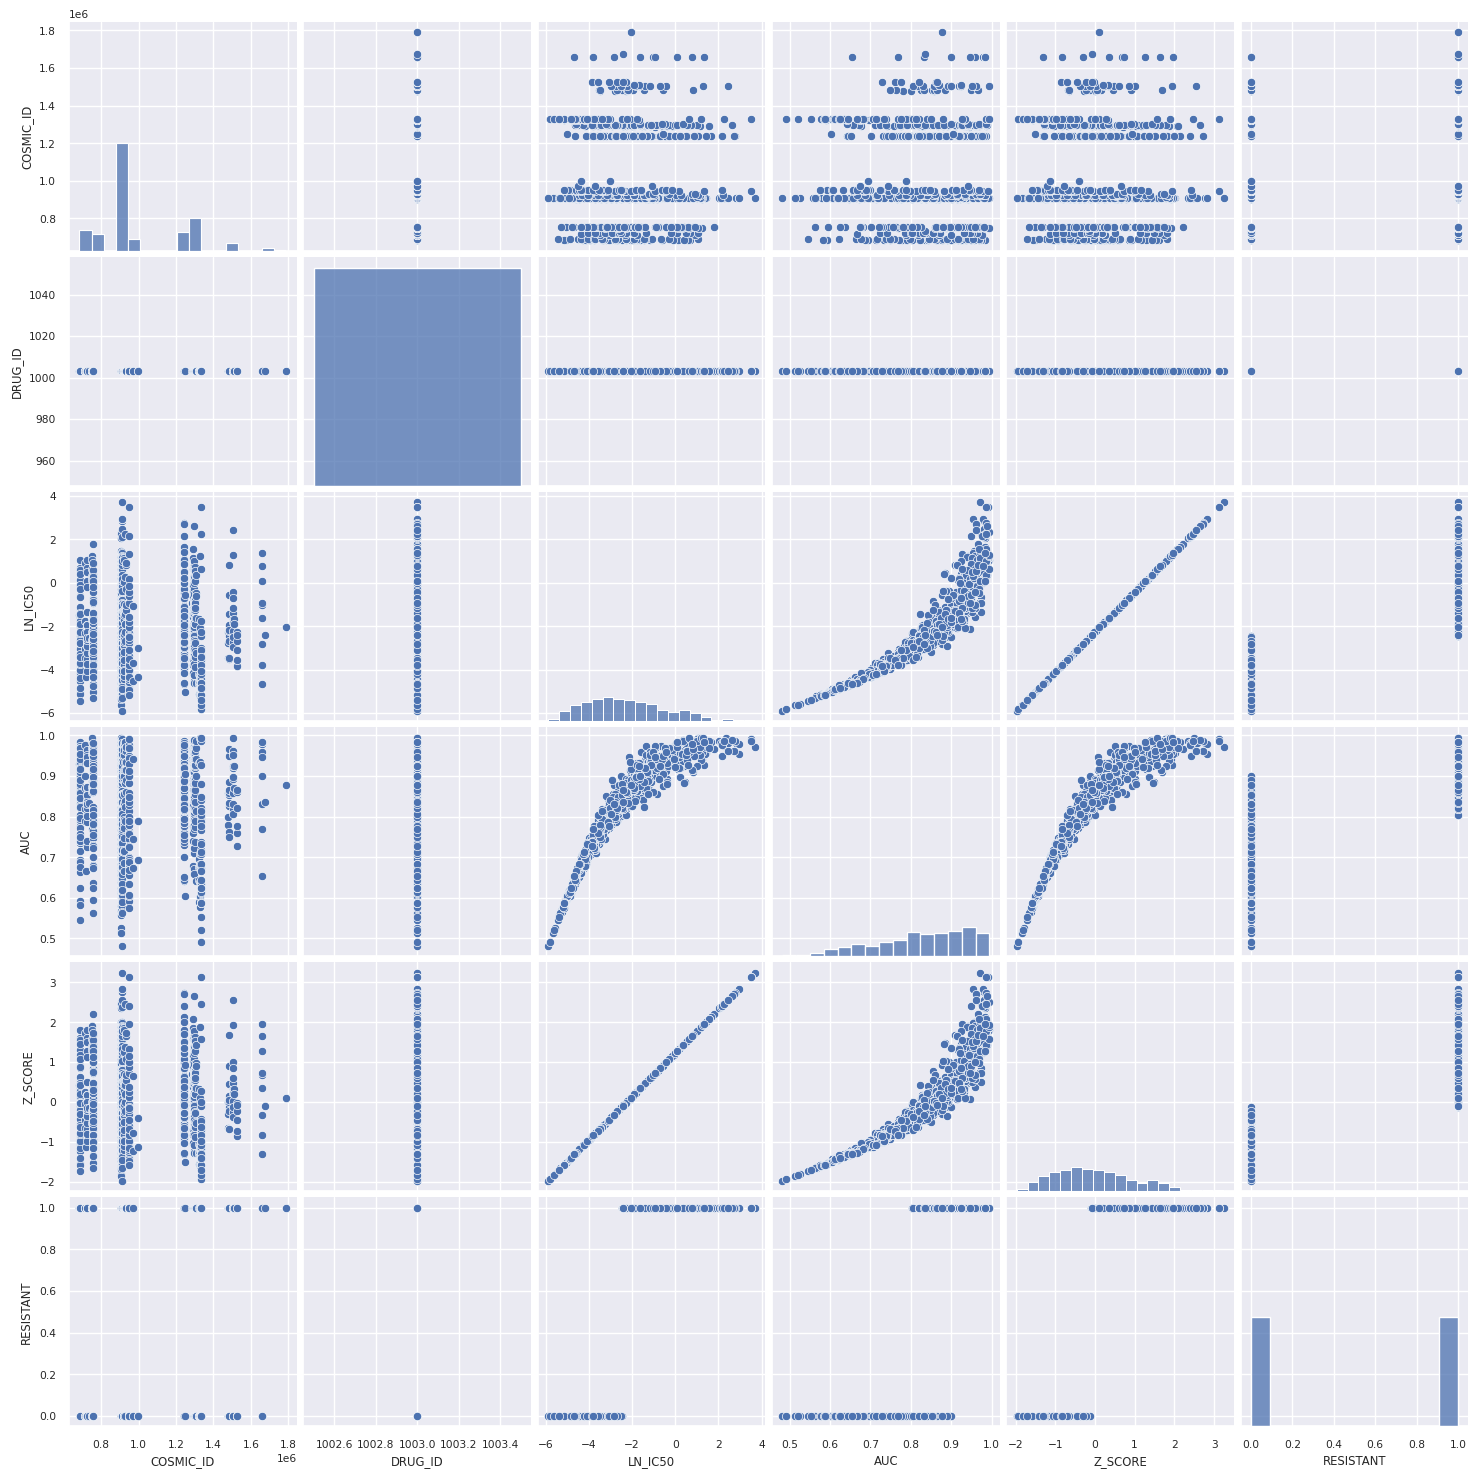

In [ ]:
# Pair plot - numeric features only to avoid errors with categoricals
sns.pairplot(df.select_dtypes(include=['int','float']), hue=None);

In [ ]:
# Create plot for ordinal and nominal categories
# This function will be used to create barplots that denote percentages for each category

def bar_plot(ax, feature):
    '''
    ax: matplotlib axis
    feature: categorical feature series
    '''
    total = len(feature) # length of the column
    for p in ax.patches:
        percentage = '{:.1f}%'.format(100 * p.get_height()/total)
        x = p.get_x() + p.get_width() / 2 - 0.05
        y = p.get_y() + p.get_height()
        ax.annotate(percentage, (x, y), size=12)
    plt.show()

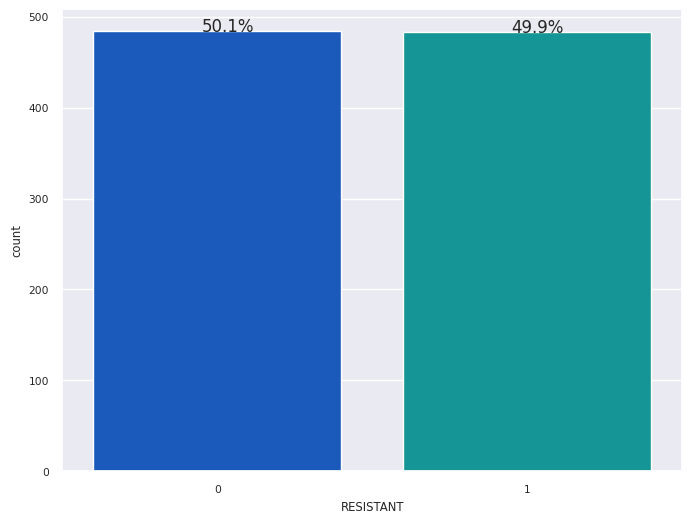

In [ ]:
# Count plot for RESISTANT (dependent variable)
plt.figure(figsize=(8,6))
ax = sns.countplot(x=df['RESISTANT'], palette='winter')
bar_plot(ax, df['RESISTANT'])

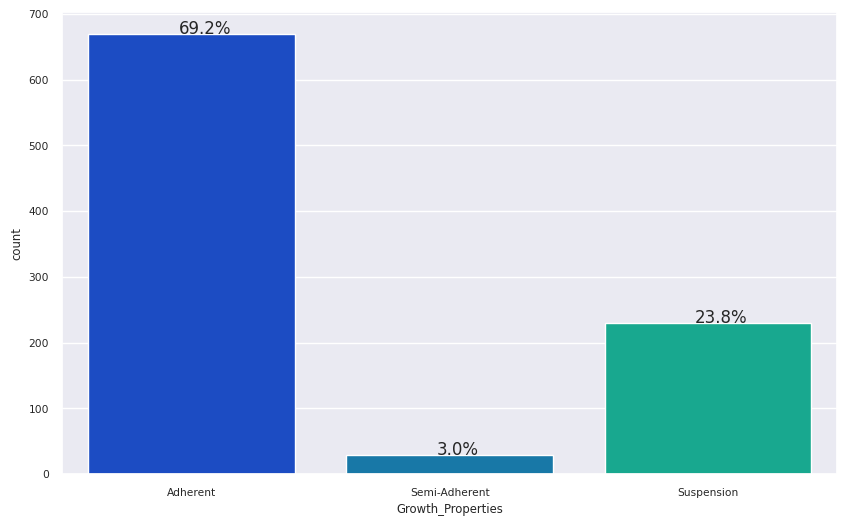

In [ ]:
# Count plot for Growth Properties
plt.figure(figsize=(10,6))
ax = sns.countplot(x=df['Growth_Properties'], palette='winter')
bar_plot(ax, df['Growth_Properties'])

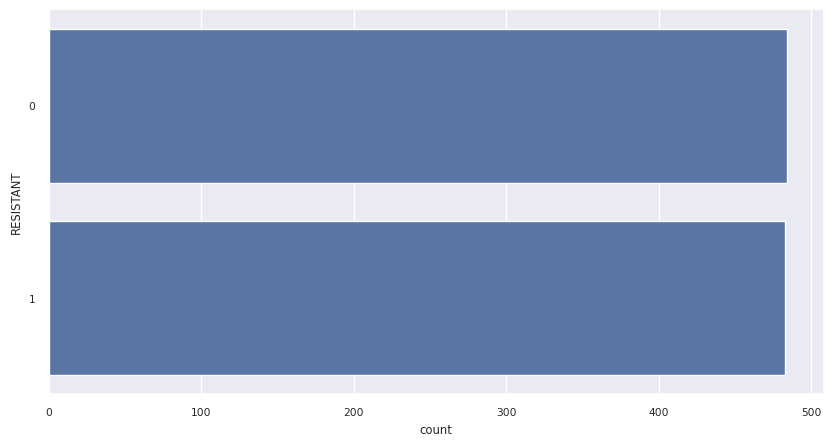

In [ ]:
# Count plot - RESISTANT
plt.figure(figsize=(10,5))
sns.countplot(y="RESISTANT", data=df,
              order=df.RESISTANT.value_counts().iloc[:2].index);

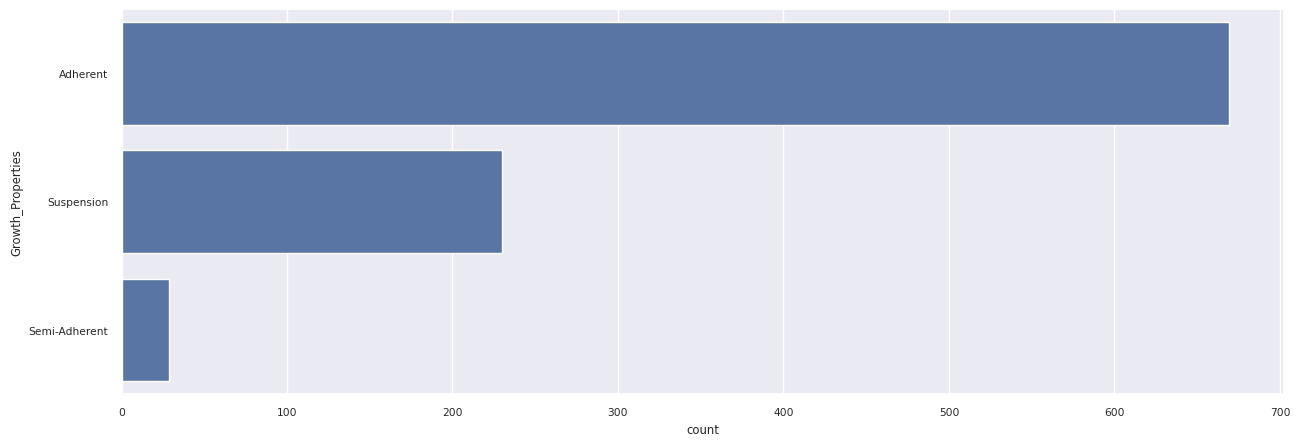

In [ ]:
# Count plot - Growth Properties
plt.figure(figsize=(15,5))
sns.countplot(y="Growth_Properties", data=df,
              order=df.Growth_Properties.value_counts().iloc[:10].index);

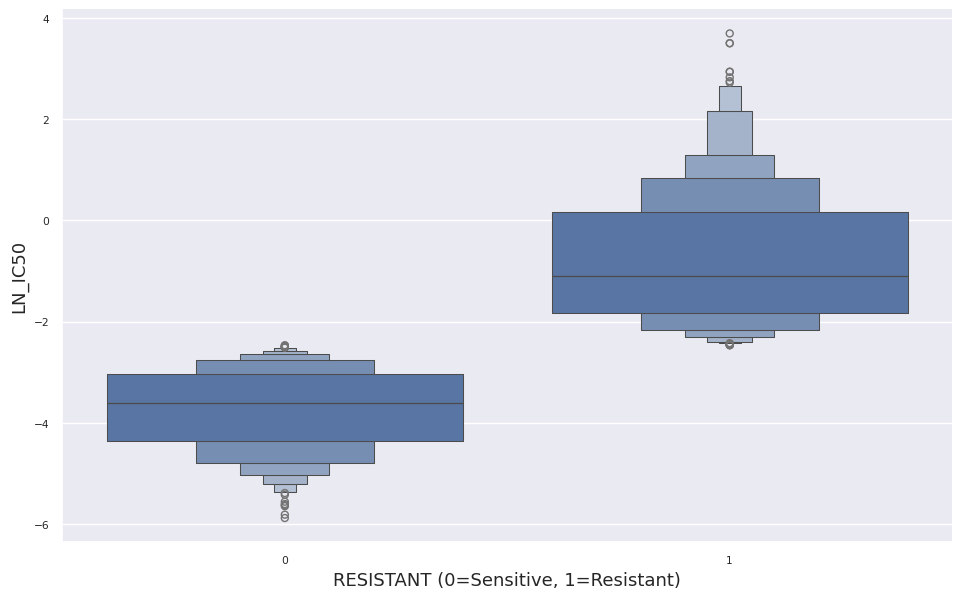

In [ ]:
# Catplot - LN_IC50 by RESISTANT group
sns.catplot(x="RESISTANT", y="LN_IC50", data=df, kind='boxen', height=6, aspect=1.6, estimator=np.mean);
plt.xlabel('RESISTANT (0=Sensitive, 1=Resistant)', fontsize=13);
plt.ylabel('LN_IC50', fontsize=13);

In [ ]:
# Create shortcut codes for commonly used variables
gp = df['Growth_Properties']
GDSC1 = df['GDSC_Tissue_descriptor_1']
GDSC2 = df['GDSC_Tissue_descriptor_2']

In [ ]:
# To only look at resistant cell lines
df.loc[df["RESISTANT"] == 1]

,COSMIC_ID,CELL_LINE_NAME,TCGA_DESC,DRUG_ID,DRUG_NAME,LN_IC50,AUC,Z_SCORE,GDSC_Tissue_descriptor_1,GDSC_Tissue_descriptor_2,Cancer_Type,MSI,Screen_Medium,Growth_Properties,CNA,Gene_Expression,Methylation,TARGET,TARGET_PATHWAY,RESISTANT
0,683667,PFSK-1,MB,1003,Camptothecin,-1.46,0.93,0.43,nervous_system,medulloblastoma,MB,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication,1
5,687448,COLO-829,SKCM,1003,Camptothecin,-1.24,0.87,0.56,skin,melanoma,SKCM,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication,1
8,687457,SW780,BLCA,1003,Camptothecin,-1.45,0.91,0.44,urogenital_system,Bladder,BLCA,MSS/MSI-L,D/F12,Adherent,Y,Y,Y,TOP1,DNA replication,1
9,687459,TCCSUP,BLCA,1003,Camptothecin,-2.35,0.84,-0.05,urogenital_system,Bladder,BLCA,MSS/MSI-L,D/F12,Adherent,Y,Y,Y,TOP1,DNA replication,1
11,687506,C-4-I,CESC,1003,Camptothecin,-2.26,0.89,0.00,urogenital_system,cervix,CESC,MSS/MSI-L,D/F12,Adherent,Y,Y,Y,TOP1,DNA replication,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
962,1660034,SNU-407,COREAD,1003,Camptothecin,-1.61,0.90,0.35,large_intestine,large_intestine,COAD/READ,MSI-H,R,Adherent,Y,Y,Y,TOP1,DNA replication,1
963,1660035,SNU-61,COREAD,1003,Camptothecin,1.34,0.98,1.96,large_intestine,large_intestine,COAD/READ,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication,1
964,1660036,SNU-81,COREAD,1003,Camptothecin,0.07,0.98,1.27,large_intestine,large_intestine,COAD/READ,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication,1
965,1674021,SNU-C5,COREAD,1003,Camptothecin,-2.42,0.84,-0.09,large_intestine,large_intestine,COAD/READ,MSI-H,R,Adherent,Y,Y,Y,TOP1,DNA replication,1


In [ ]:
# Make a copy of your dataframe
copy = df

In [ ]:
# Use this function to create a boxplot and histogram for each numeric variable
def histogram_boxplot(feature, figsize=(12,8), bins=None):
    """ Boxplot and histogram combined
    feature: 1-d feature array
    figsize: size of fig (default (12,8))
    bins: number of bins (default None / auto)
    """
    sns.set(font_scale=2)
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,
        sharex=True,
        gridspec_kw={"height_ratios": (.25, .75)},
        figsize=figsize
    )
    sns.boxplot(x=feature, ax=ax_box2, showmeans=True, color='red')
    if bins:
        sns.histplot(feature, ax=ax_hist2, bins=bins, kde=False)
    else:
        sns.histplot(feature, ax=ax_hist2, kde=True, stat='density')
        xmin, xmax = ax_hist2.get_xlim()
        x = np.linspace(xmin, xmax, 100)
        p = norm.pdf(x, np.mean(feature), np.std(feature))
        ax_hist2.plot(x, p, 'k', linewidth=2)
    ax_hist2.axvline(np.mean(feature), color='black', linestyle='--', label='Mean')
    ax_hist2.axvline(np.median(feature), color='g', linestyle='-', label='Median')
    ax_hist2.axvline(feature.mode()[0], color='r', linestyle='dashed', linewidth=1, label='Mode')
    ax_hist2.legend(fontsize=12)
    plt.tight_layout()

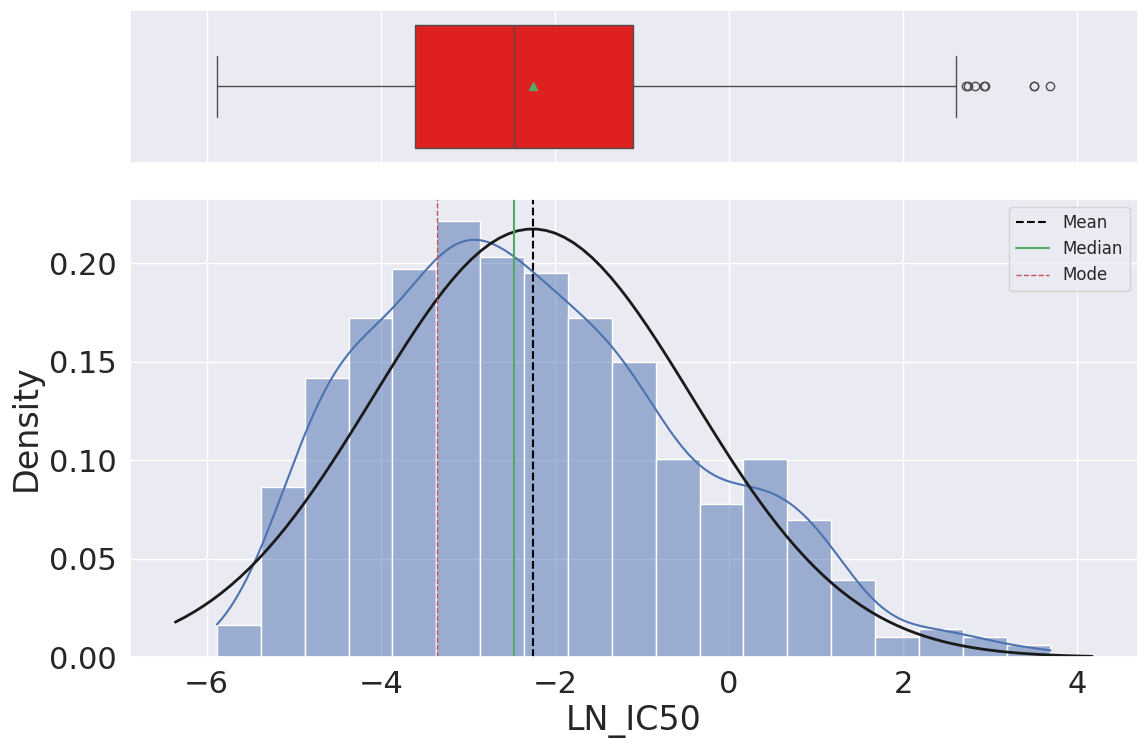

In [ ]:
histogram_boxplot(df.LN_IC50)

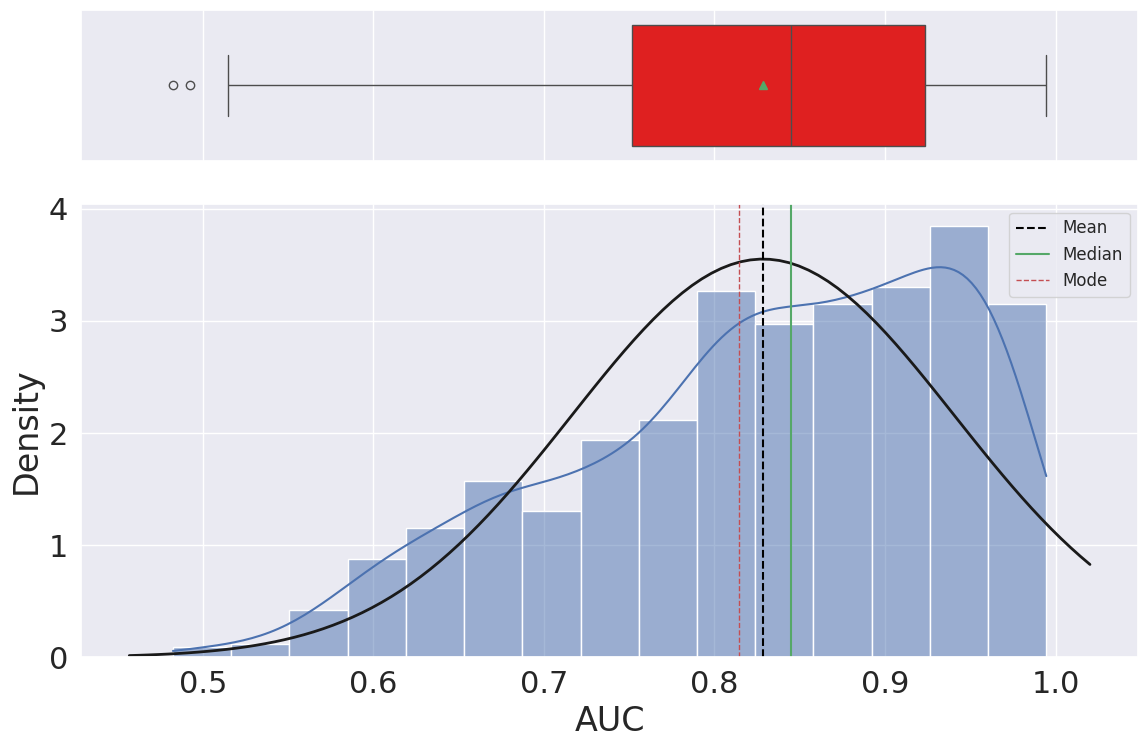

In [ ]:
histogram_boxplot(df.AUC)

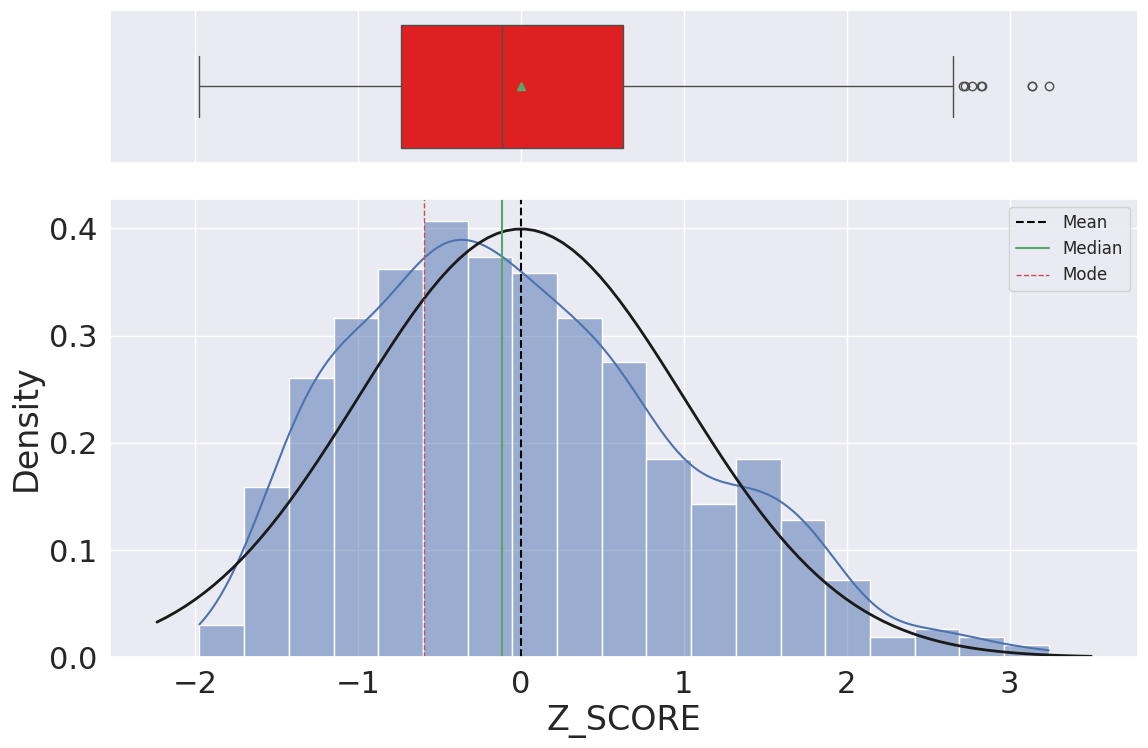

In [ ]:
histogram_boxplot(df.Z_SCORE)

In [ ]:
# Number of unique values in RESISTANT
df.RESISTANT.nunique()

2

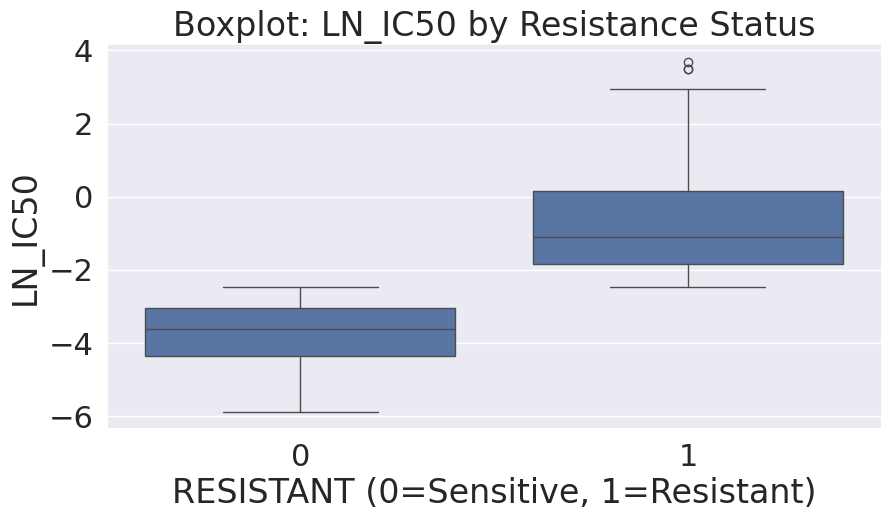

In [ ]:
# Boxplot with DV and 1 IV
plt.figure(figsize=(10,5))
sns.boxplot(x="RESISTANT", y="LN_IC50", data=df)
plt.title('Boxplot: LN_IC50 by Resistance Status')
plt.xlabel('RESISTANT (0=Sensitive, 1=Resistant)')
plt.show()

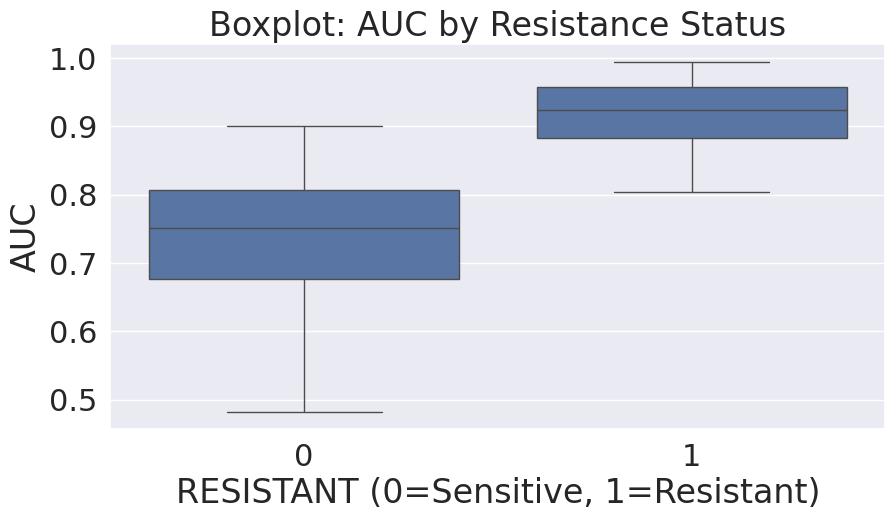

In [ ]:
plt.figure(figsize=(10,5))
sns.boxplot(x="RESISTANT", y="AUC", data=df)
plt.title('Boxplot: AUC by Resistance Status')
plt.xlabel('RESISTANT (0=Sensitive, 1=Resistant)')
plt.show()

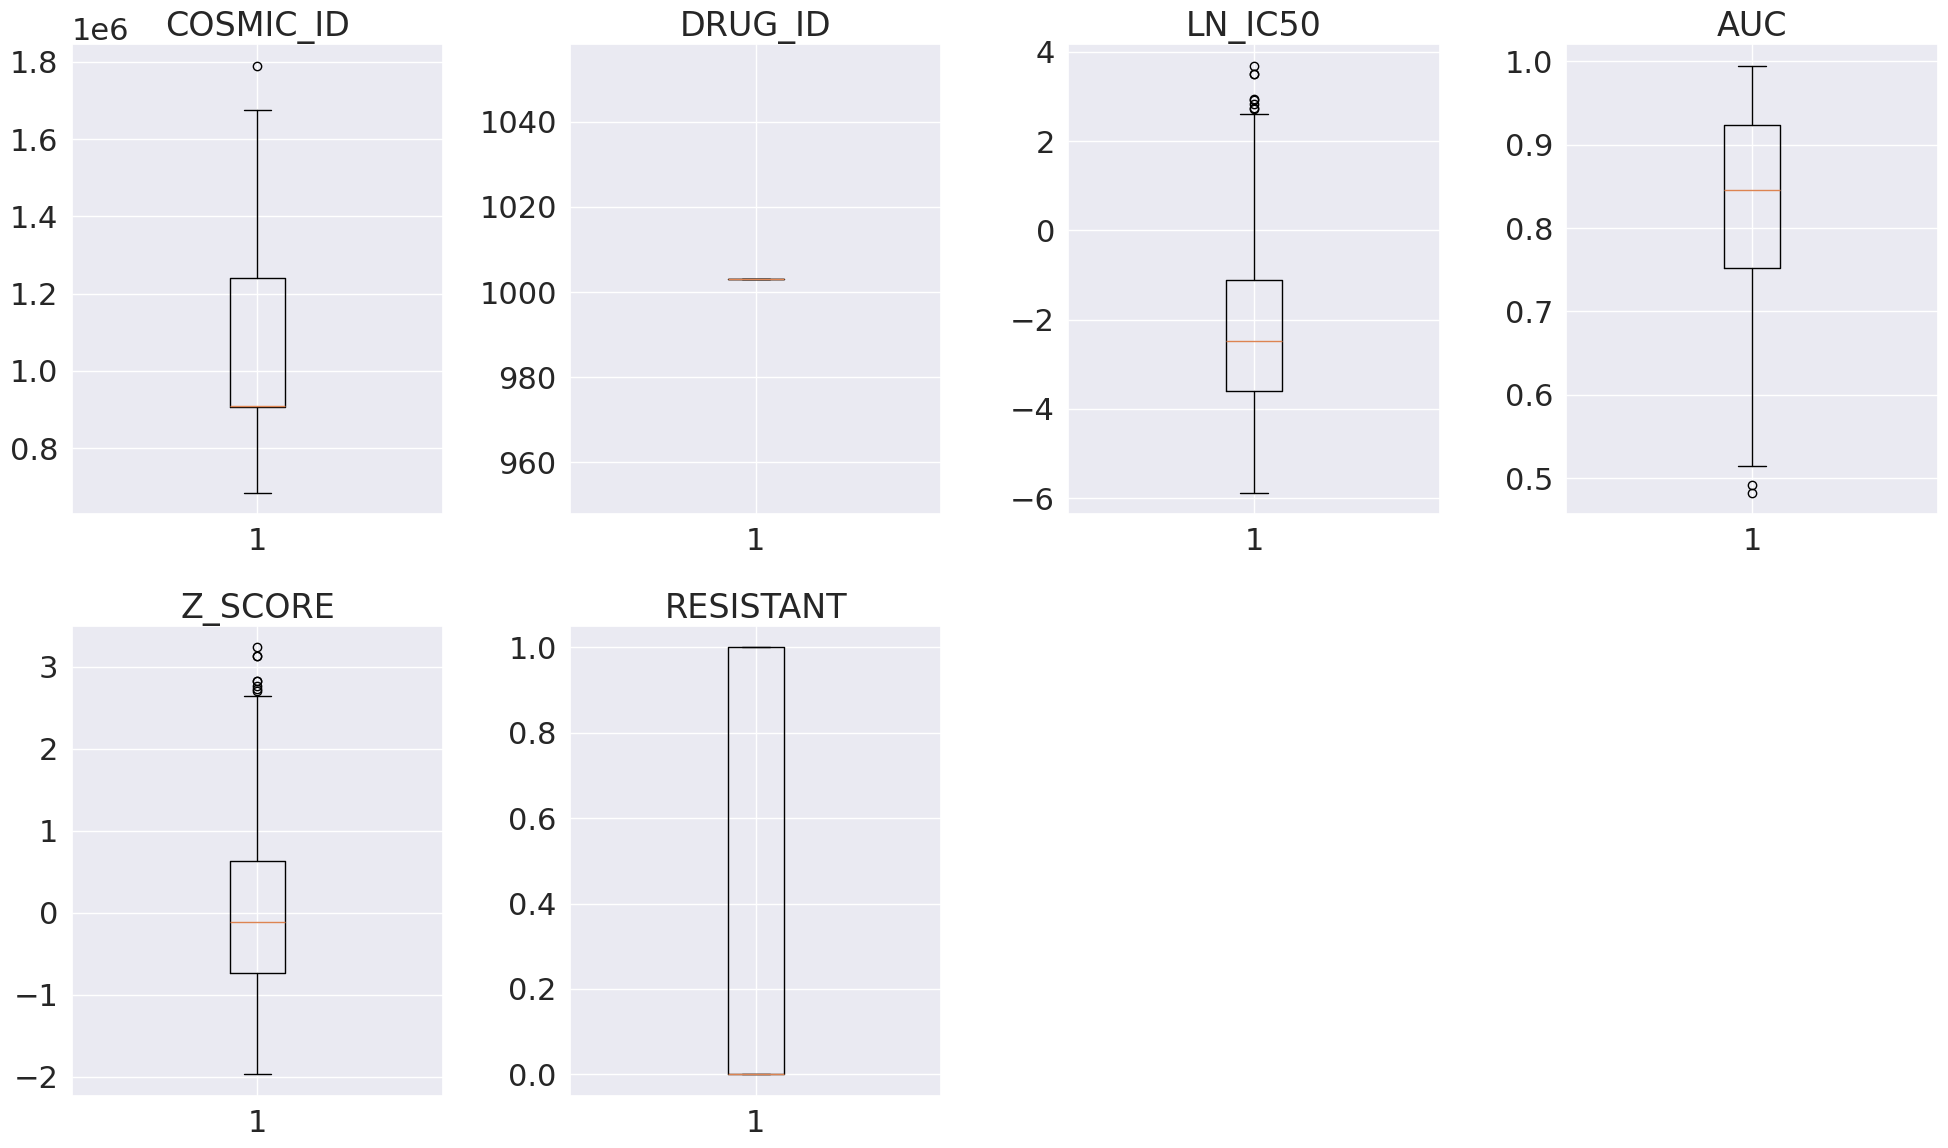

In [ ]:
# Outlier detection using boxplots (for all numeric variables)
numeric_cols = df.select_dtypes(include=['int', 'float']).columns.tolist()
plt.figure(figsize=(20, 12))

for i, variable in enumerate(numeric_cols):
    plt.subplot(2, 4, i+1)
    plt.boxplot(df[variable].dropna(), whis=1.5)
    plt.tight_layout()
    plt.title(variable)

plt.show()

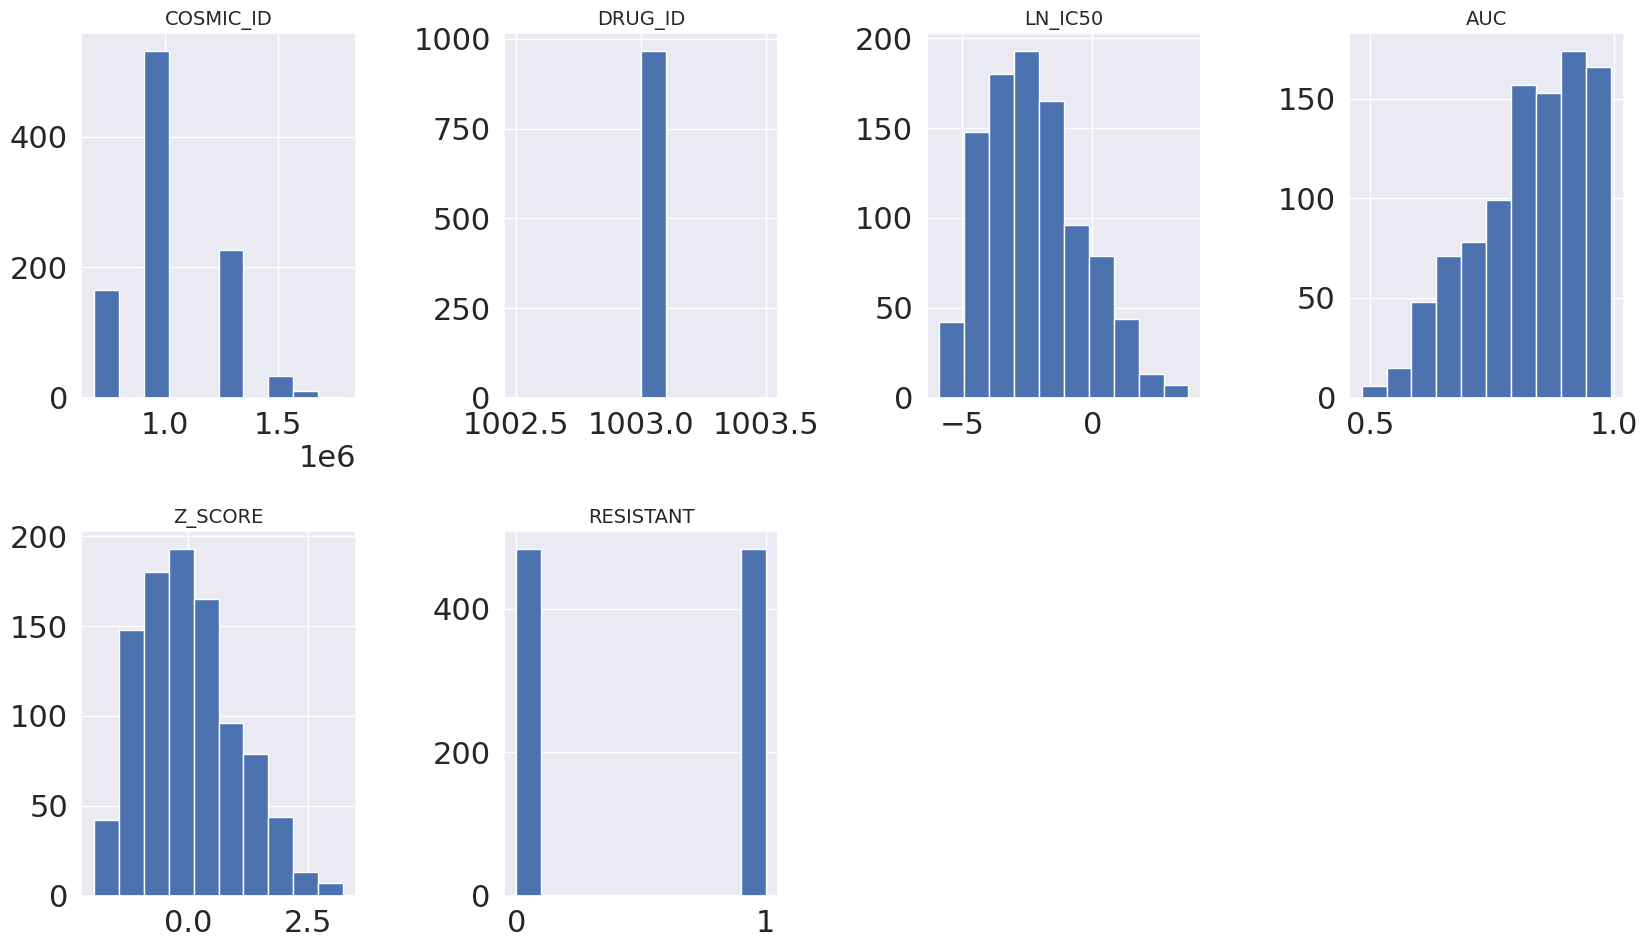

In [ ]:
# Plot histogram to check the distribution of each numeric variable
all_col = df.select_dtypes(include=np.number).columns.tolist()
plt.figure(figsize=(17, 10))

for i in range(len(all_col)):
    plt.subplot(2, 4, i+1)
    plt.hist(df[all_col[i]].dropna())
    plt.tight_layout()
    plt.title(all_col[i], fontsize=14)

plt.show()

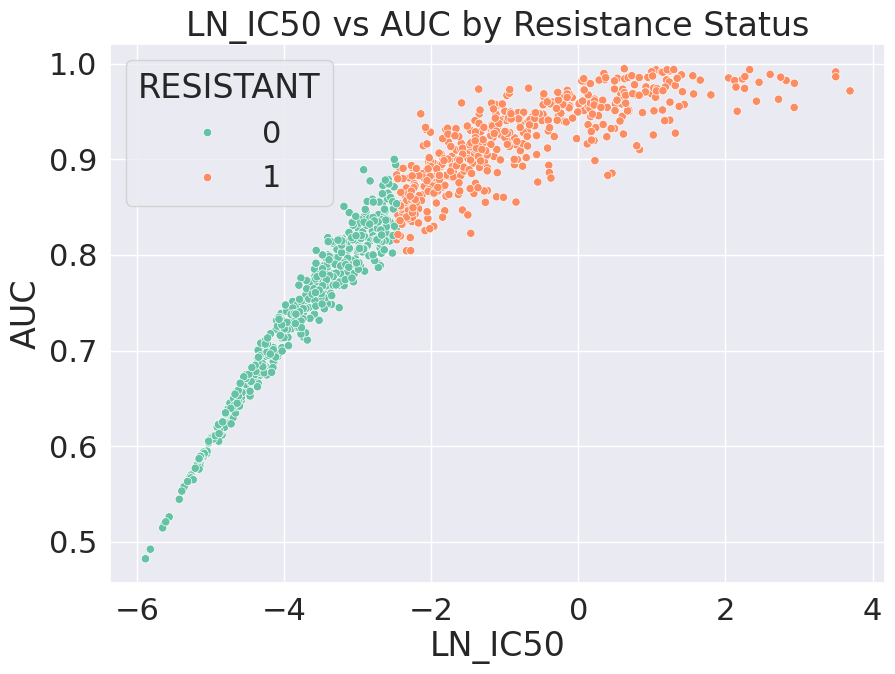

In [ ]:
# Scatterplot: LN_IC50 vs AUC colored by resistance status
plt.figure(figsize=(10,7))
sns.scatterplot(x=df.LN_IC50, y=df.AUC, hue=df['RESISTANT'], palette='Set2');
plt.title('LN_IC50 vs AUC by Resistance Status');

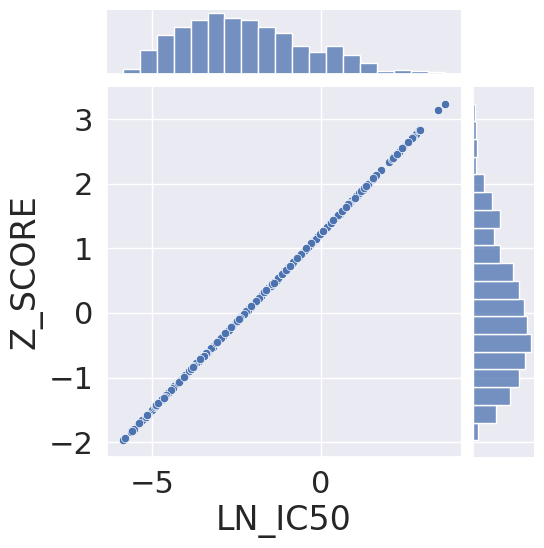

In [ ]:
# Joint plot: LN_IC50 vs Z_SCORE
sns.jointplot(x=df['LN_IC50'], y=df['Z_SCORE'], kind='scatter');

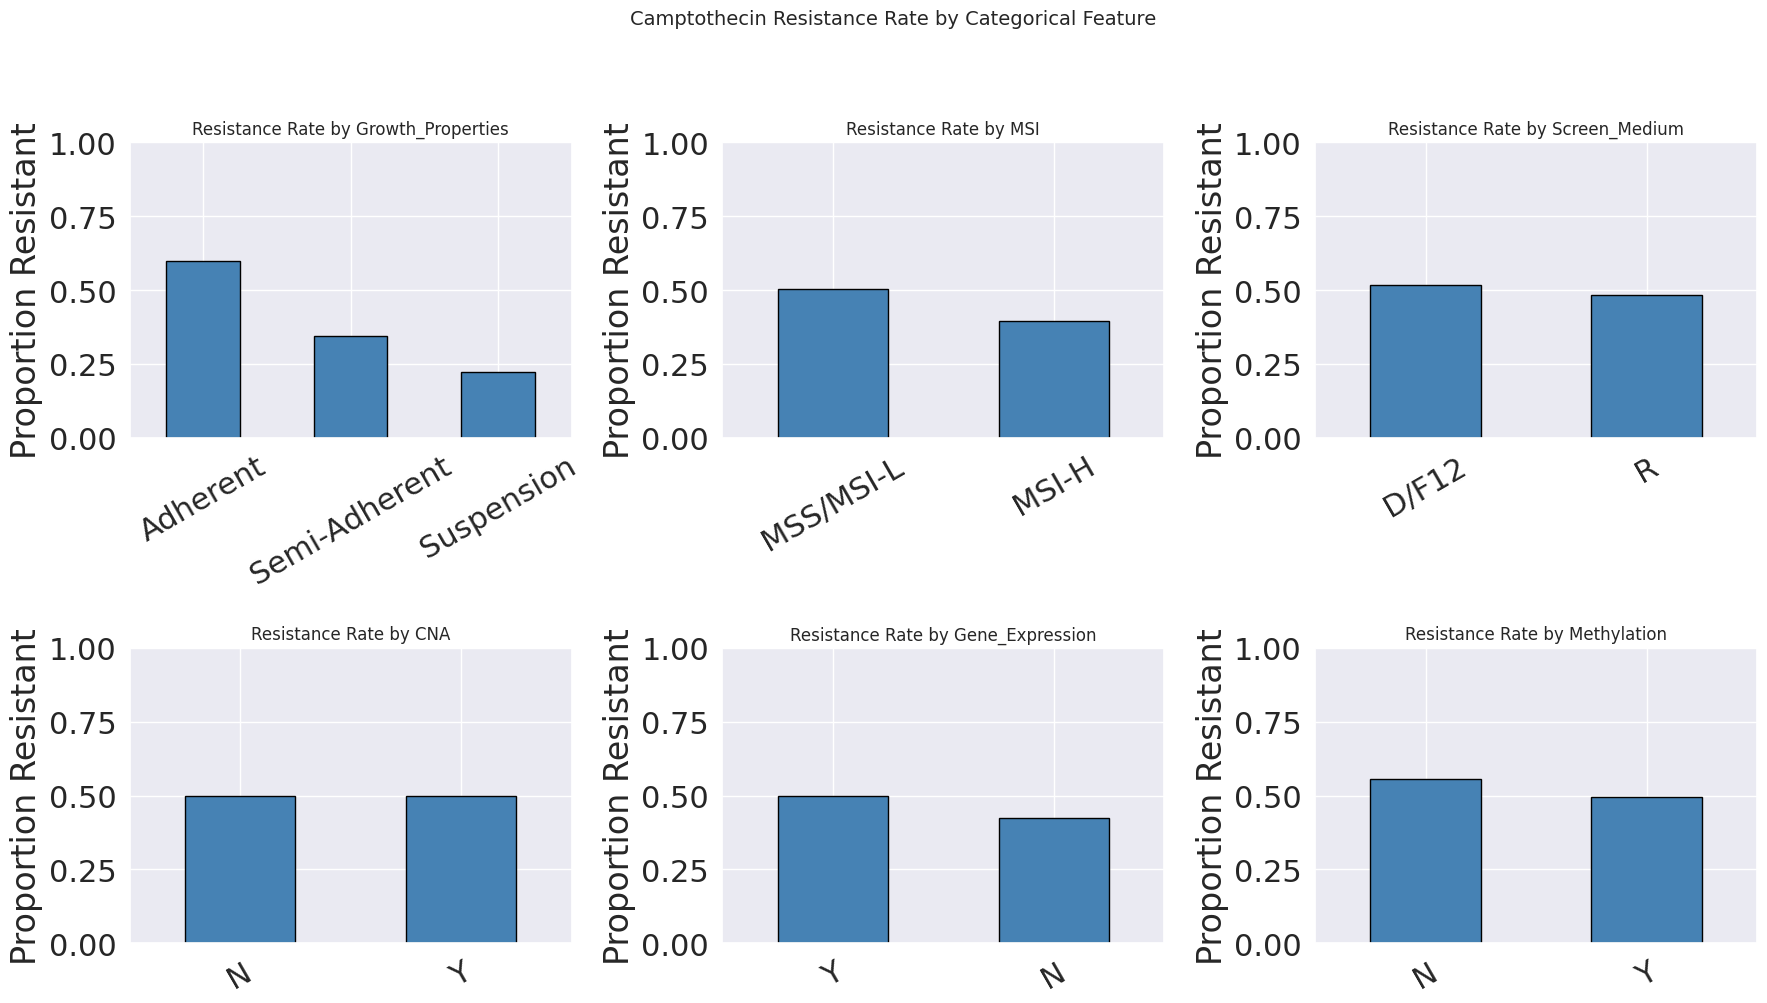

In [ ]:
# Resistance rate by categorical features
cat_features = ['Growth_Properties', 'MSI', 'Screen_Medium', 'CNA', 'Gene_Expression', 'Methylation']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    resist_rate = df.groupby(col, observed=True)['RESISTANT'].mean().sort_values(ascending=False)
    resist_rate.plot(kind='bar', ax=axes[i], color='steelblue', edgecolor='black')
    axes[i].set_title(f'Resistance Rate by {col}', fontsize=12)
    axes[i].set_ylabel('Proportion Resistant')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].set_ylim(0, 1)

plt.suptitle('Camptothecin Resistance Rate by Categorical Feature', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

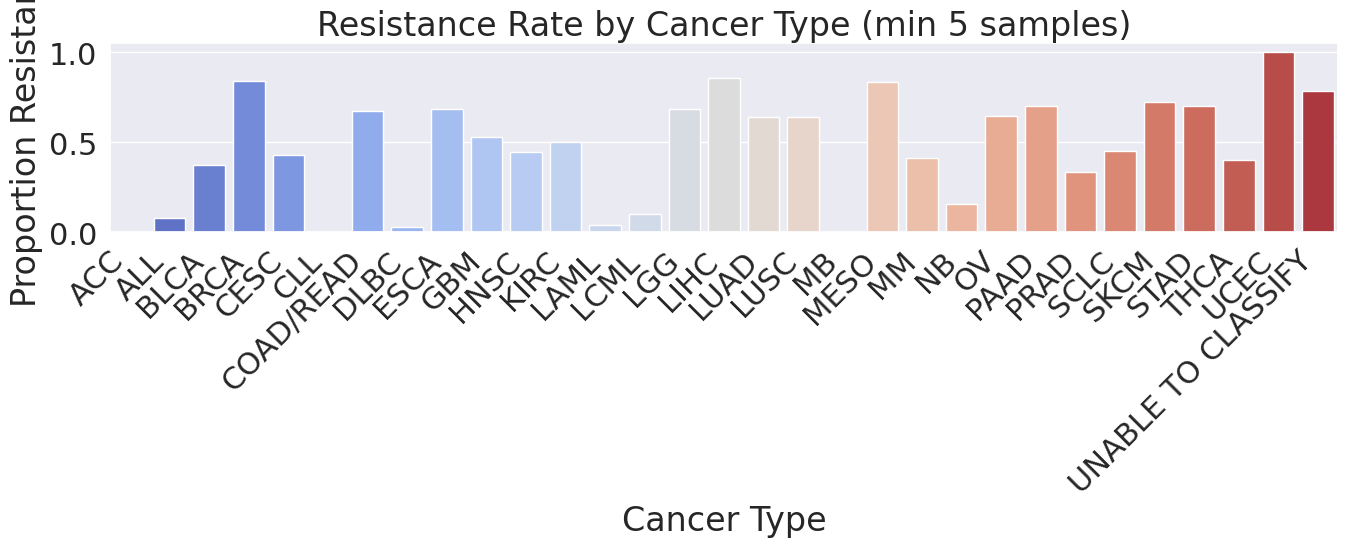

In [ ]:
# Top cancer types by resistance rate (min 5 samples)
cancer_resist = df.groupby('Cancer_Type', observed=True)['RESISTANT'].agg(['mean','count'])
cancer_resist = cancer_resist[cancer_resist['count'] >= 5].sort_values('mean', ascending=False)

plt.figure(figsize=(14, 6))
sns.barplot(x=cancer_resist.index, y=cancer_resist['mean'], palette='coolwarm')
plt.title('Resistance Rate by Cancer Type (min 5 samples)')
plt.ylabel('Proportion Resistant')
plt.xlabel('Cancer Type')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## My Custom Visualizations
Most of the independent variables in my data are categorical, so I wanted to do some more EDA specifically focused on the relationship between my categorical independent variables and my dependent variable.

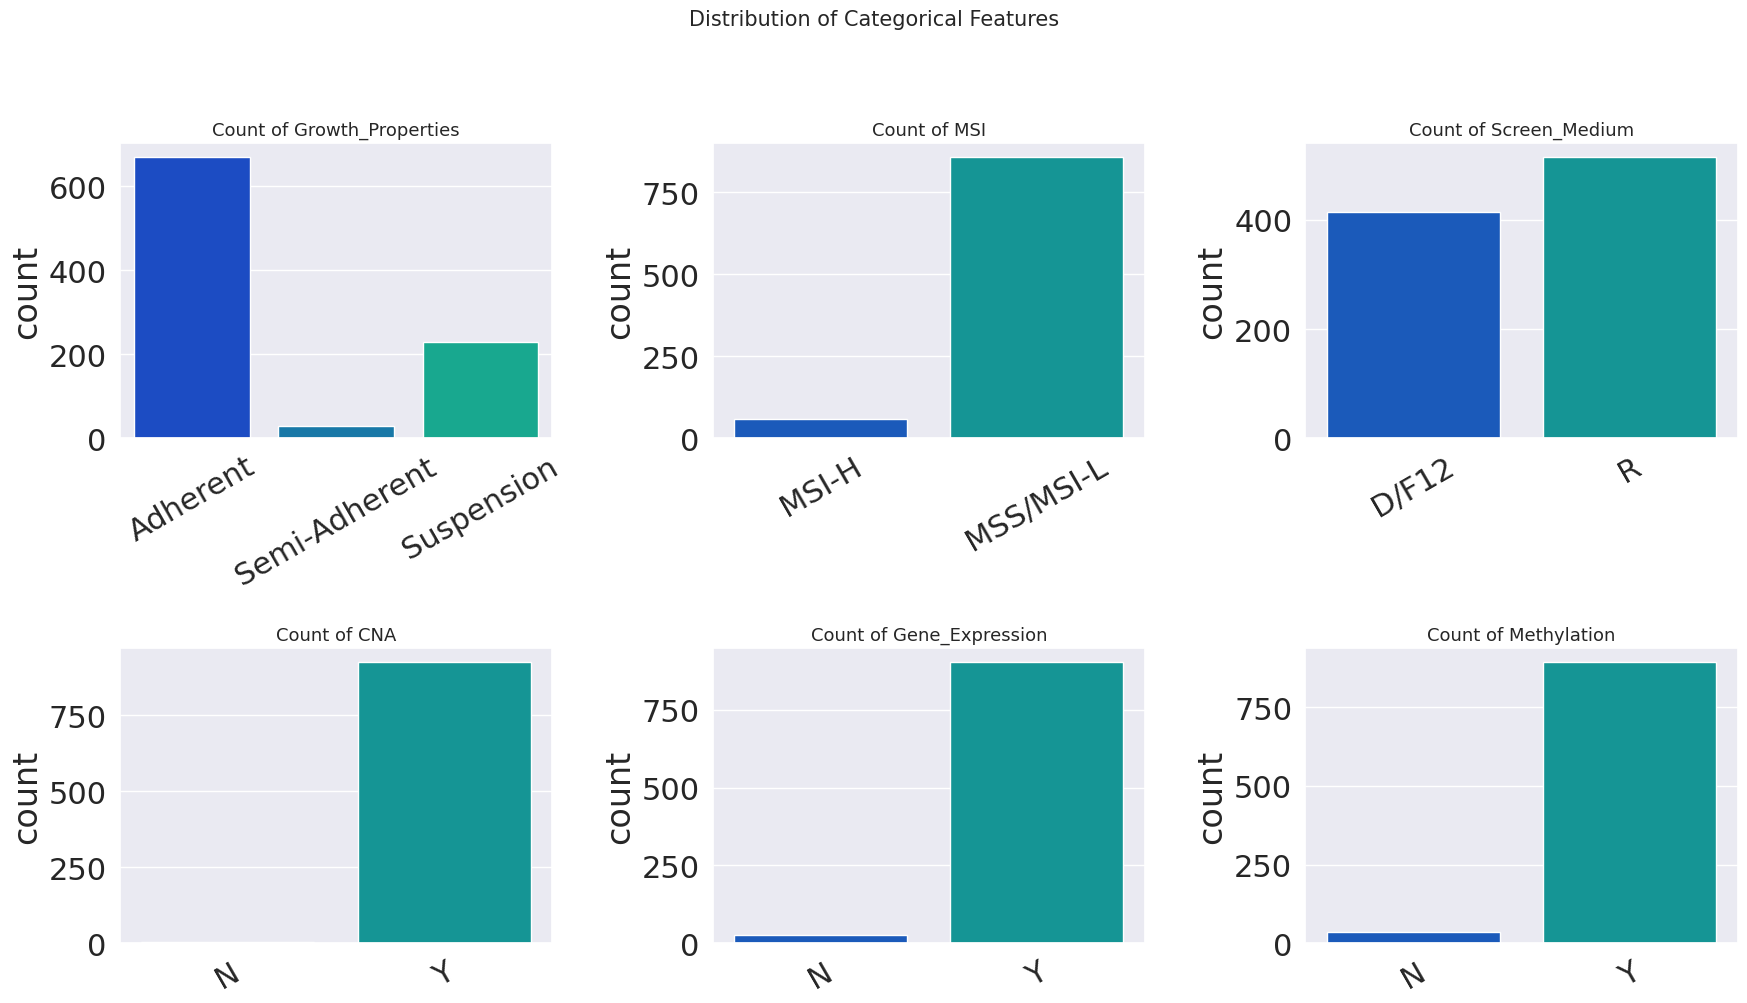

In [ ]:
# Count plots for each categorical feature
# These show the raw distribution of each category across the dataset

cat_features = ['Growth_Properties', 'MSI', 'Screen_Medium', 'CNA', 'Gene_Expression', 'Methylation']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    ax = axes[i]
    # countplot tallies how many rows fall into each category level
    sns.countplot(x=col, data=df, palette='winter', ax=ax)
    ax.set_title(f'Count of {col}', fontsize=13)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Distribution of Categorical Features', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

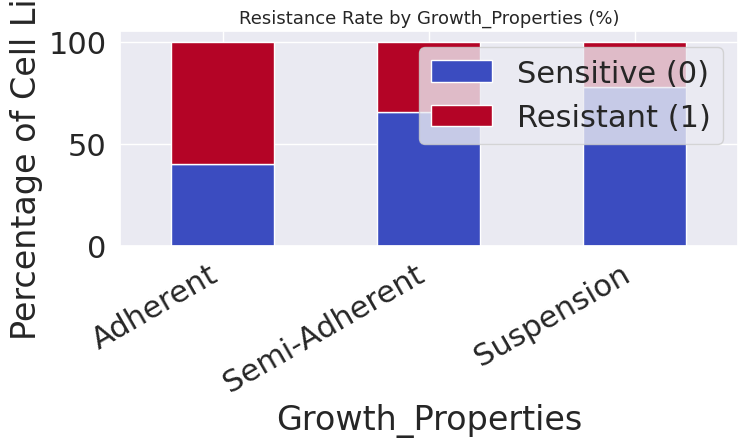

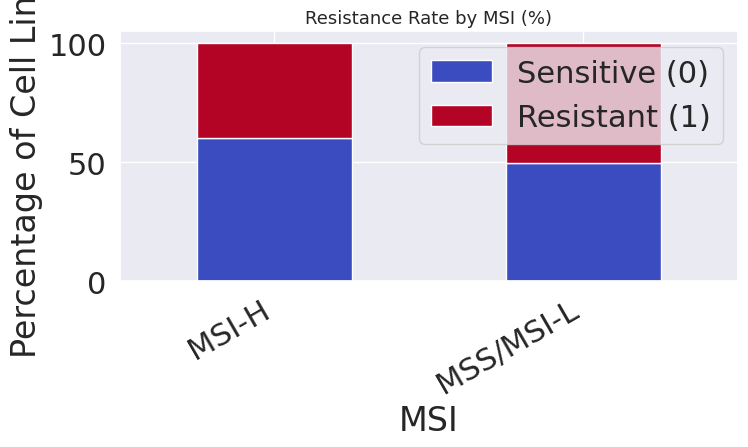

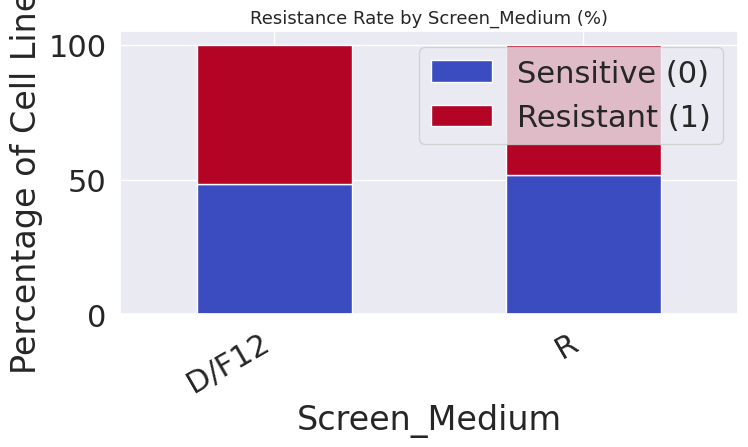

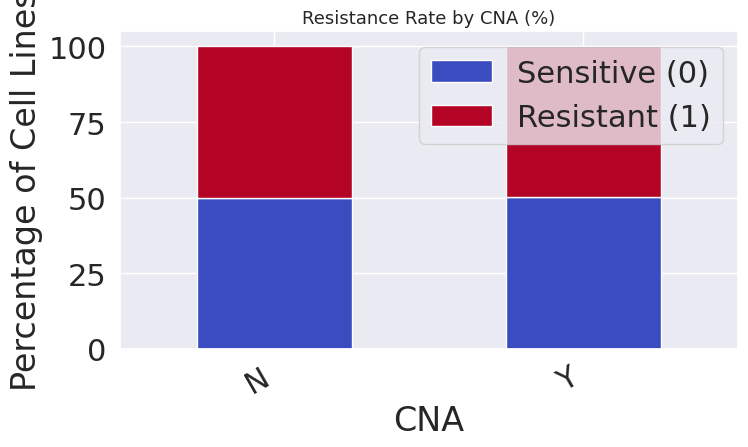

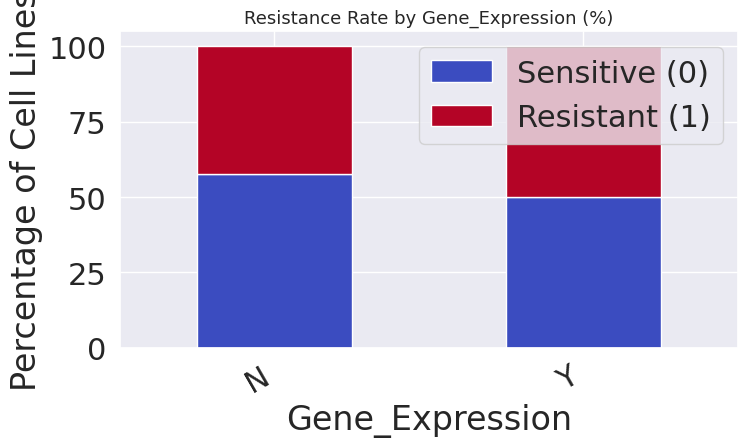

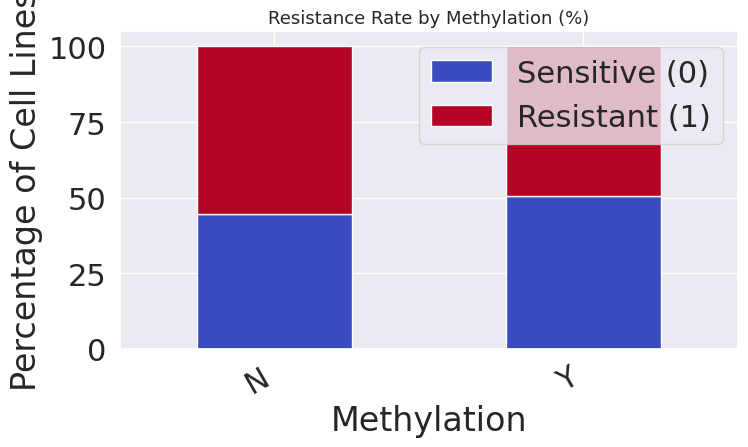

In [ ]:
# Stacked bar chart of resistance rate per category
# within each group, what fraction of cell lines are resistant?

cat_features = ['Growth_Properties', 'MSI', 'Screen_Medium', 'CNA', 'Gene_Expression', 'Methylation']

for col in cat_features:
    # Build a cross-tabulation normalized by row to get resistance proportion per group
    ct = pd.crosstab(df[col], df['RESISTANT'], normalize='index') * 100
    ct.columns = ['Sensitive (0)', 'Resistant (1)']

    ct.plot(kind='bar', stacked=True, colormap='coolwarm', figsize=(8, 5))
    plt.title(f'Resistance Rate by {col} (%)', fontsize=13)
    plt.ylabel('Percentage of Cell Lines')
    plt.xlabel(col)
    plt.legend(loc='upper right')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

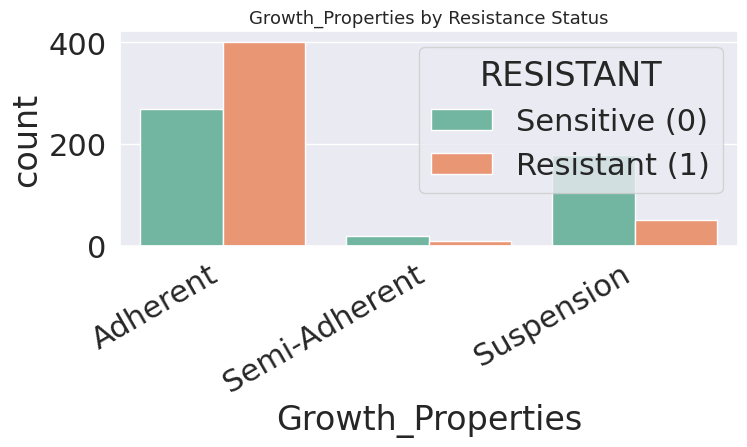

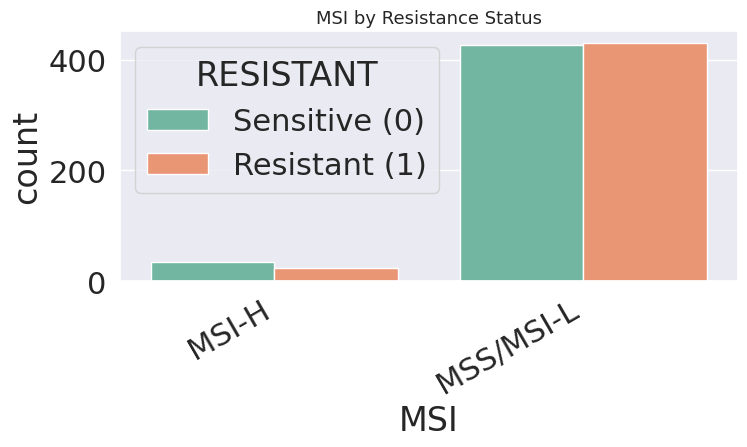

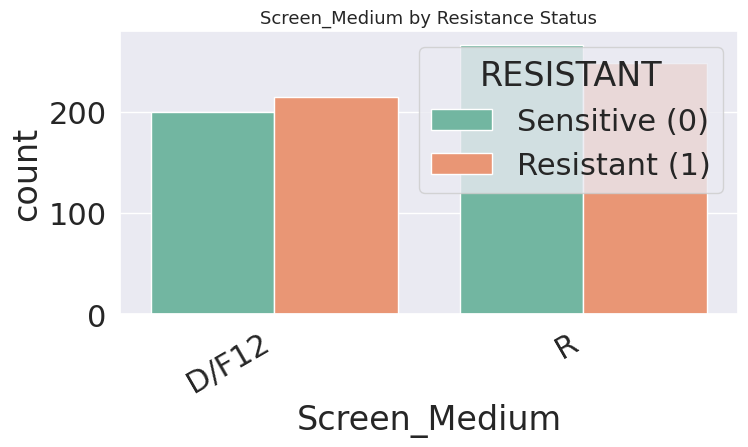

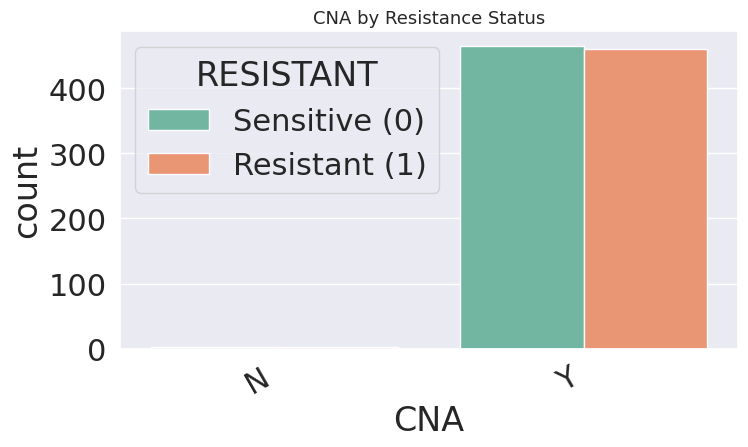

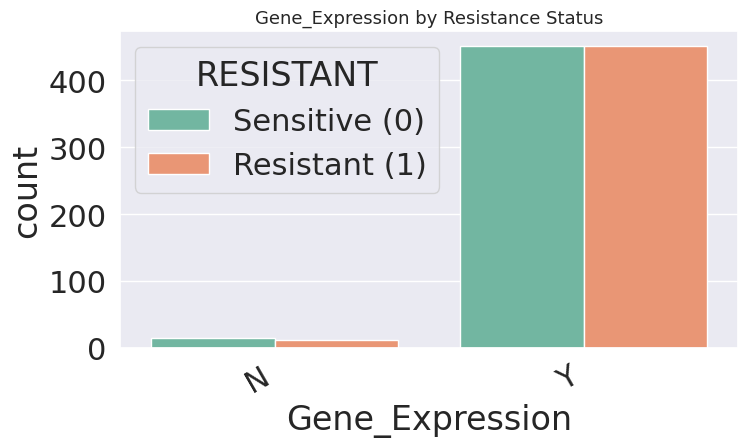

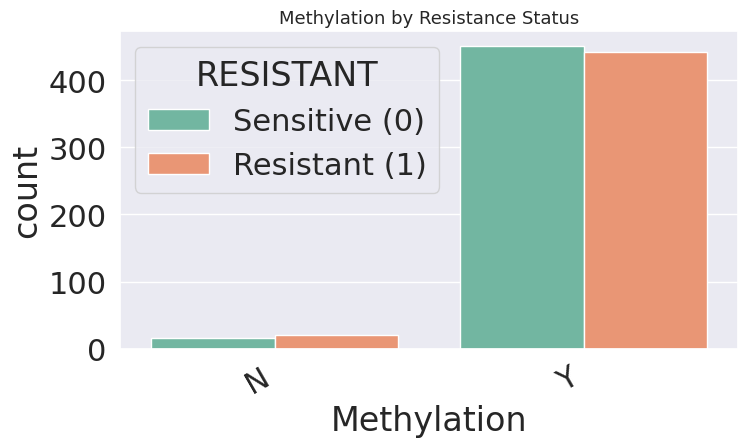

In [ ]:
# Grouped count plot with RESISTANT as color
# Useful for visually comparing sensitive vs resistant counts within each group

cat_features = ['Growth_Properties', 'MSI', 'Screen_Medium', 'CNA', 'Gene_Expression', 'Methylation']

for col in cat_features:
    plt.figure(figsize=(8, 5))
    # hue splits each category into two bars: sensitive (0) and resistant (1)
    sns.countplot(x=col, hue='RESISTANT', data=df, palette='Set2')
    plt.title(f'{col} by Resistance Status', fontsize=13)
    plt.xlabel(col)
    plt.legend(title='RESISTANT', labels=['Sensitive (0)', 'Resistant (1)'])
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()